In [1]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:45661")
client

<Client: 'tcp://127.0.0.1:45661' processes=8 threads=32, memory=503.70 GiB>

In [2]:
import numpy as np
import xarray as xr
import pandas as pd
from xhistogram.xarray import histogram as xhist
from xgcm.grid import Grid
import gsw

import rioxarray
import seaborn as sns
import xrft

import glob

import gcm_filters

import os.path as op

from scipy.interpolate import griddata, interpn

import warnings
warnings.filterwarnings("ignore")

# from xeofs.models import EOF
from pydmd import DMD, BOPDMD, MrDMD
from pydmd.mrcosts import mrCOSTS
from pydmd.preprocessing import hankel_preprocessing
from pydmd.plotter import plot_eigs, plot_summary

from matplotlib import ticker
import matplotlib.colors as clr
import matplotlib.pyplot as plt
plt.rcParams['pcolor.shading'] = 'auto'
%matplotlib inline

In [3]:
grav = 9.807
meth = "linear"
ddir = "/storage/tartar/takaya/swot/"

# Agulhas Rings

In [42]:
ds01 = xr.open_zarr(op.join(ddir,"SWOT_no_IT/CalVal_pass%03d_v2.0.1.zarr"
                            % 1))
ds01.coords["num_lines"] = ("num_lines",range(len(ds01.num_lines)))
ds01.coords["num_pixels"] = ("num_pixels",range(len(ds01.num_pixels)))

ds16 = xr.open_zarr(op.join(ddir,"SWOT_no_IT/CalVal_pass%03d_v2.0.1.zarr"
                            % 16))
ds16.coords["num_lines"] = ("num_lines",range(len(ds16.num_lines)))
ds16.coords["num_pixels"] = ("num_pixels",range(len(ds16.num_pixels)))
ds01,ds16

(<xarray.Dataset> Size: 582MB
 Dimensions:       (cycle_num: 105, num_lines: 9860, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 79kB 0 1 2 3 4 ... 9855 9856 9857 9858 9859
   * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 68
     latitude      (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9860, 69), meta=np.ndarray>
     longitude     (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9860, 69), meta=np.ndarray>
 Data variables:
     ssha_detided  (cycle_num, num_lines, num_pixels) float64 571MB dask.array<chunksize=(1, 9860, 69), meta=np.ndarray>,
 <xarray.Dataset> Size: 582MB
 Dimensions:       (cycle_num: 105, num_lines: 9860, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 79kB 0 1 2 3 4 ... 9855 9856 9857 9858 9859
   * num_pixels  

In [43]:
maskn1 = xr.DataArray(ds01.latitude.where(ds01.latitude>-38.2).to_masked_array().mask,
                     dims=ds01.latitude.dims,
                     coords=ds01.latitude.coords
                    )
masks1 = xr.DataArray(ds01.latitude.where(ds01.latitude<-33).to_masked_array().mask,
                     dims=ds01.latitude.dims,
                     coords=ds01.latitude.coords
                    )
xo01 = ds01.where(~maskn1,drop=True).where(~masks1,drop=True)

maskn6 = xr.DataArray(ds16.latitude.where(ds16.latitude>-38.2).to_masked_array().mask,
                     dims=ds16.latitude.dims,
                     coords=ds16.latitude.coords
                    )
masks6 = xr.DataArray(ds16.latitude.where(ds16.latitude<-33).to_masked_array().mask,
                     dims=ds16.latitude.dims,
                     coords=ds16.latitude.coords
                    )
xo16 = ds16.where(~maskn6,drop=True).where(~masks6,drop=True)
xo01, xo16

(<xarray.Dataset> Size: 18MB
 Dimensions:       (cycle_num: 105, num_lines: 310, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 2kB 2777 2778 2779 2780 ... 3084 3085 3086
   * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 68
     latitude      (num_lines, num_pixels) float64 171kB -38.19 -38.2 ... -33.0
     longitude     (num_lines, num_pixels) float64 171kB 14.54 14.56 ... 17.44
 Data variables:
     ssha_detided  (cycle_num, num_lines, num_pixels) float64 18MB dask.array<chunksize=(1, 310, 69), meta=np.ndarray>,
 <xarray.Dataset> Size: 18MB
 Dimensions:       (cycle_num: 105, num_lines: 310, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 2kB 6775 6776 6777 6778 ... 7082 7083 7084
   * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 

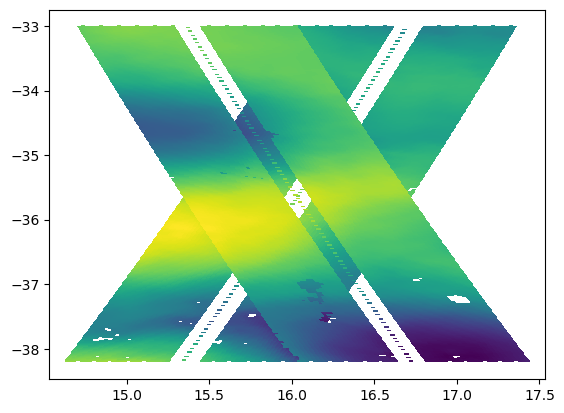

In [44]:
fig, ax = plt.subplots()
ax.pcolormesh(xo01.longitude, xo01.latitude,
              xo01.ssha_detided.isel(cycle_num=10),
              rasterized=True
             )
ax.pcolormesh(xo16.longitude, xo16.latitude,
              xo16.ssha_detided.isel(cycle_num=10),
              rasterized=True
             )

In [45]:
inp = 3

mask01 = xr.DataArray(xo01.ssha_detided.to_masked_array().mask.mean(axis=0), 
                     dims=xo01.ssha_detided.isel(cycle_num=0).dims, 
                     coords=xo01.ssha_detided.isel(cycle_num=0).coords
                    )
mm01 = xr.DataArray(mask01.where(mask01<.5
                              ).to_masked_array().mask,
                   dims=xo01.ssha_detided.isel(cycle_num=0).dims, 
                   coords=xo01.ssha_detided.isel(cycle_num=0).coords
                  ).isel(num_pixels=slice(inp,-inp))
mask16 = xr.DataArray(xo16.ssha_detided.to_masked_array().mask.mean(axis=0), 
                     dims=xo16.ssha_detided.isel(cycle_num=0).dims, 
                     coords=xo16.ssha_detided.isel(cycle_num=0).coords
                    )
mm16 = xr.DataArray(mask16.where(mask16<.5
                              ).to_masked_array().mask,
                   dims=xo16.ssha_detided.isel(cycle_num=0).dims, 
                   coords=xo16.ssha_detided.isel(cycle_num=0).coords
                  ).isel(num_pixels=slice(inp,-inp))
mm01, mm16

(<xarray.DataArray (num_lines: 310, num_pixels: 63)> Size: 20kB
 array([[ True,  True,  True, ...,  True,  True,  True],
        [ True, False, False, ...,  True,  True,  True],
        [ True, False, False, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ..., False, False,  True],
        [ True,  True,  True, ..., False, False,  True],
        [ True,  True,  True, ...,  True,  True,  True]], shape=(310, 63))
 Coordinates:
   * num_lines   (num_lines) int64 2kB 2777 2778 2779 2780 ... 3084 3085 3086
   * num_pixels  (num_pixels) int64 504B 3 4 5 6 7 8 9 ... 59 60 61 62 63 64 65
     cycle_num   int64 8B 474
     latitude    (num_lines, num_pixels) float64 156kB -38.2 -38.21 ... -32.99
     longitude   (num_lines, num_pixels) float64 156kB 14.61 14.63 ... 17.38,
 <xarray.DataArray (num_lines: 310, num_pixels: 63)> Size: 20kB
 array([[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ..., False, False,  True],
        [ True,  True,  Tr

In [46]:
low01 = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass%03d/SSHa.zarr" 
                               % 1)
                      ).ssha.where(~maskn1,drop=True).where(~masks1,drop=True)
low16 = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass%03d/SSHa.zarr" 
                               % 16)
                      ).ssha.where(~maskn6,drop=True).where(~masks6,drop=True)
low01, low16

(<xarray.DataArray 'ssha' (cycle_num: 105, num_lines: 308, num_pixels: 61)> Size: 16MB
 dask.array<where, shape=(105, 308, 61), dtype=float64, chunksize=(1, 308, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 2kB 2778 2779 2780 2781 ... 3083 3084 3085
   * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
     latitude    (num_lines, num_pixels) float64 150kB -38.19 -38.19 ... -33.01
     longitude   (num_lines, num_pixels) float64 150kB 14.64 14.66 ... 17.35,
 <xarray.DataArray 'ssha' (cycle_num: 105, num_lines: 308, num_pixels: 61)> Size: 16MB
 dask.array<where, shape=(105, 308, 61), dtype=float64, chunksize=(1, 308, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 2kB 6776 6777 6778 6779 ... 7081 7082 7083
   * num_pixels  (num_pixels) int

In [47]:
r_ref1 = (~mm01).sum() / np.prod(mm01.shape)
r_ref6 = (~mm16).sum() / np.prod(mm16.shape)
r_ref6

<xarray.DataArray ()> Size: 8B
array(0.80491551)
Coordinates:
    cycle_num  int64 8B 474

In [48]:
ageo = (1e-2*ds01.ssha_detided
        - low01
       )
ic = 0
for cc in ageo.cycle_num:

    sshg = low01.sel(cycle_num=cc)
    ssha = ageo.sel(cycle_num=cc)
    
    array = ssha.to_masked_array()
    mask = ~array.mask
    ratio = mask.sum() / np.prod(mask.shape)
    if ic == 0:
        r01 = xr.DataArray(np.array([ratio]), 
                           dims='cycle_num', 
                           coords={'cycle_num':np.array([cc.values,])}
                          )
    else:
        r01 = xr.concat([r01, xr.DataArray(np.array([ratio]), 
                               dims='cycle_num', 
                               coords={'cycle_num':np.array([cc.values,])}
                                          )
                        ], 'cycle_num')
    if ratio > .7*r_ref1:
        if ic == 0:
            a01 = ssha
        else:
            try:
                a01 = xr.concat([a01, ssha], 'cycle_num')
            except:
                pass
        ic += 1
    # else:
    #     ssha.plot(rasterized=True)
    #     plt.show()
    del ssha, mask, array

a01.coords["cycle_num"] = ("cycle_num",
                           r01.where(r01>0.7*r_ref1, drop=True).cycle_num.data
                          )

dsa01 = a01.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsa01.coords["y"] = ("y",range(len(dsa01.y)))
dsa01.coords["x"] = ("x",range(len(dsa01.x)))
if not dsa01.rio.crs:
    dsa01 = dsa01.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsa01.ssha.rio.nodata is None:
    dsa01["ssha"] = dsa01.ssha.rio.write_nodata(np.nan)
_a01_exterp = dsa01.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_a01_interp = _a01_exterp.interp(cycle_num=ds01.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
a01_exterp = _a01_exterp.where(mm01.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds01.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsa01.close()

dsg01 = low01.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsg01.coords["y"] = ("y",range(len(dsg01.y)))
dsg01.coords["x"] = ("x",range(len(dsg01.x)))
if not dsg01.rio.crs:
    dsg01 = dsg01.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsg01.ssha.rio.nodata is None:
    dsg01["ssha"] = dsg01.ssha.rio.write_nodata(np.nan)
_g01_exterp = dsg01.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_g01_interp = _g01_exterp.interp(cycle_num=ds01.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
g01_exterp = _g01_exterp.where(mm01.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds01.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsg01.close()

In [49]:
ageo = (1e-2*ds16.ssha_detided
        - low16
       )
ic = 0
for cc in ageo.cycle_num:

    sshg = low16.sel(cycle_num=cc)
    ssha = ageo.sel(cycle_num=cc)
    
    array = ssha.to_masked_array()
    mask = ~array.mask
    ratio = mask.sum() / np.prod(mask.shape)
    if ic == 0:
        r16 = xr.DataArray(np.array([ratio]), 
                           dims='cycle_num', 
                           coords={'cycle_num':np.array([cc.values,])}
                          )
    else:
        r16 = xr.concat([r16, xr.DataArray(np.array([ratio]), 
                               dims='cycle_num', 
                               coords={'cycle_num':np.array([cc.values,])}
                                          )
                        ], 'cycle_num')
    if ratio > .7*r_ref6:
        if ic == 0:
            a16 = ssha
        else:
            try:
                a16 = xr.concat([a16, ssha], 'cycle_num')
            except:
                pass
        ic += 1
    # else:
    #     ssha.plot(rasterized=True)
    #     plt.show()
    del ssha, mask, array

a16.coords["cycle_num"] = ("cycle_num",
                           r16.where(r16>0.7*r_ref6, drop=True).cycle_num.data
                          )

dsa16 = a16.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsa16.coords["y"] = ("y",range(len(dsa16.y)))
dsa16.coords["x"] = ("x",range(len(dsa16.x)))
if not dsa16.rio.crs:
    dsa16 = dsa16.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsa16.ssha.rio.nodata is None:
    dsa16["ssha"] = dsa16.ssha.rio.write_nodata(np.nan)
_a16_exterp = dsa16.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_a16_interp = _a16_exterp.interp(cycle_num=ds16.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
a16_exterp = _a16_exterp.where(mm16.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds16.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsa16.close()

dsg16 = low16.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsg16.coords["y"] = ("y",range(len(dsg16.y)))
dsg16.coords["x"] = ("x",range(len(dsg16.x)))
if not dsg16.rio.crs:
    dsg16 = dsg16.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsg16.ssha.rio.nodata is None:
    dsg16["ssha"] = dsg16.ssha.rio.write_nodata(np.nan)
_g16_exterp = dsg16.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_g16_interp = _g16_exterp.interp(cycle_num=ds16.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
g16_exterp = _g16_exterp.where(mm16.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds16.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsg16.close()

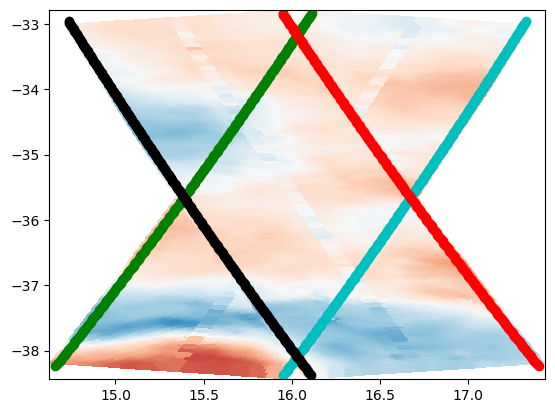

In [50]:
fig, ax = plt.subplots()
ax.pcolormesh(a01_exterp.longitude, a01_exterp.latitude,
              _a01_interp.isel(cycle_num=10),
              vmax=.3, vmin=-.3, cmap="RdBu_r",
              rasterized=True
             )
ax.pcolormesh(a16_exterp.longitude, a16_exterp.latitude,
              _a16_interp.isel(cycle_num=10),
              vmax=.3, vmin=-.3, cmap="RdBu_r",
              rasterized=True
             )
ax.scatter(a01_exterp.longitude.isel(num_pixels=1), a01_exterp.latitude.isel(num_pixels=13), c="g")
ax.scatter(a01_exterp.longitude.isel(num_pixels=-2), a01_exterp.latitude.isel(num_pixels=-14), c="c")
ax.scatter(a16_exterp.longitude.isel(num_pixels=1), a16_exterp.latitude.isel(num_pixels=13), c="r")
ax.scatter(a16_exterp.longitude.isel(num_pixels=-2), a16_exterp.latitude.isel(num_pixels=-14), c="k")

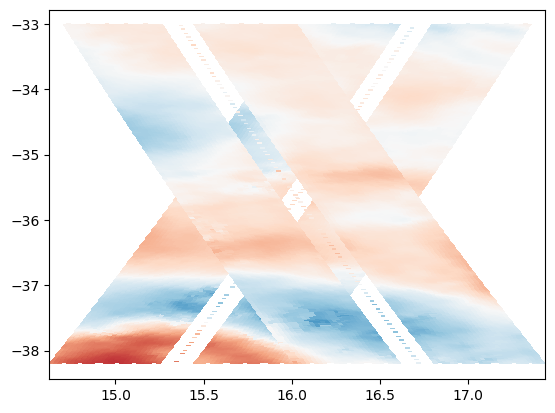

In [51]:
fig, ax = plt.subplots()
ax.pcolormesh(a01_exterp.longitude, a01_exterp.latitude,
              a01_exterp.isel(cycle_num=11),
              vmax=.3, vmin=-.3, cmap="RdBu_r",
              rasterized=True
             )
ax.pcolormesh(a16_exterp.longitude, a16_exterp.latitude,
              a16_exterp.isel(cycle_num=11),
              vmax=.3, vmin=-.3, cmap="RdBu_r",
              rasterized=True
             )

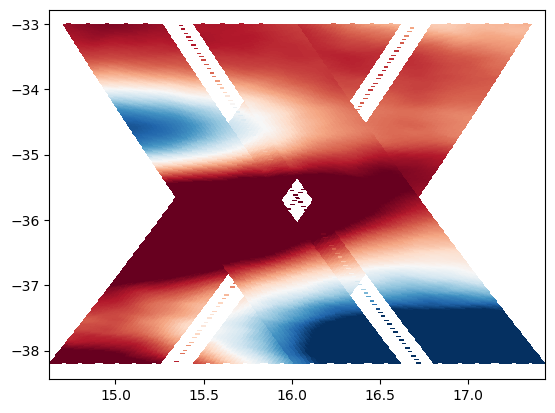

In [52]:
fig, ax = plt.subplots()
ax.pcolormesh(g01_exterp.longitude, g01_exterp.latitude,
              g01_exterp.isel(cycle_num=11),
              vmax=.3, vmin=-.3, cmap="RdBu_r",
              rasterized=True
             )
ax.pcolormesh(g16_exterp.longitude, g16_exterp.latitude,
              g16_exterp.isel(cycle_num=11),
              vmax=.3, vmin=-.3, cmap="RdBu_r",
              rasterized=True
             )

In [51]:
for cc in low01.cycle_num:
    if cc == low01.cycle_num[0]:
        ar_g = g01_exterp.sel(cycle_num=cc).isel(num_pixels=[13,-14]
                                                ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        ar_a = a01_exterp.sel(cycle_num=cc).isel(num_pixels=[13,-14]
                                                ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])

        ar_g = xr.concat([ar_g, 
                          g16_exterp.sel(cycle_num=cc).isel(num_pixels=[-14,13]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_a = xr.concat([ar_a, 
                          a16_exterp.sel(cycle_num=cc).isel(num_pixels=[-14,13]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
    else:
        tmp_g = g01_exterp.sel(cycle_num=cc).isel(num_pixels=[13,-14]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        tmp_a = a01_exterp.sel(cycle_num=cc).isel(num_pixels=[13,-14]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])

        tmp_g = xr.concat([tmp_g, 
                          g16_exterp.sel(cycle_num=cc).isel(num_pixels=[-14,13]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        tmp_a = xr.concat([tmp_a, 
                          a16_exterp.sel(cycle_num=cc).isel(num_pixels=[-14,13]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_g = xr.concat([ar_g, tmp_g], "time")
        ar_a = xr.concat([ar_a, tmp_a], "time")

ar_g.coords["time"] = ("time",np.arange(len(ar_g.time))*12*60.*60)
ar_a.coords["time"] = ("time",np.arange(len(ar_a.time))*12*60.*60)
ar_g.coords["num_lines"] = ("num_lines",np.arange(len(ar_g.num_lines))*2e3)
ar_a.coords["num_lines"] = ("num_lines",np.arange(len(ar_a.num_lines))*2e3)

ar_g, ar_a

(<xarray.DataArray 'ssha' (time: 210, num_lines: 287, num_pixels: 2)> Size: 964kB
 array([[[-0.07953933, -0.27083454],
         [-0.0811116 , -0.27487113],
         [-0.08318581, -0.27915451],
         ...,
         [ 0.00328775, -0.00625227],
         [ 0.00197513, -0.00510696],
         [ 0.00081777, -0.00485588]],
 
        [[ 0.13841637,  0.09778645],
         [ 0.13661896,  0.09569437],
         [ 0.13480191,  0.09331102],
         ...,
         [-0.46161997, -0.45715204],
         [-0.4656737 , -0.45962381],
         [-0.46981929, -0.4625363 ]],
 
        [[-0.00294253, -0.29549077],
         [-0.00308193, -0.29578217],
         [-0.00314041, -0.29669727],
         ...,
 ...
         ...,
         [-0.45466449, -0.52534181],
         [-0.45431264, -0.52912016],
         [-0.45380292, -0.53299691]],
 
        [[-0.06026213, -0.32196599],
         [-0.06480071, -0.33085342],
         [-0.07006566, -0.33943798],
         ...,
         [-0.04733263, -0.01100891],
         [-0.0439474

In [53]:
for cc in low01.cycle_num:
    if cc == low01.cycle_num[0]:
        ar_g1 = g01_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        ar_a1 = a01_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])

        ar_g6 = g16_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        ar_a6 = a16_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
    else:
        ar_g1 = xr.concat([ar_g1, 
                          g01_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_a1 = xr.concat([ar_a1, 
                          a01_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_g6 = xr.concat([ar_g6, 
                          g16_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_a6 = xr.concat([ar_a6, 
                          a16_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")

ar_g1.coords["time"] = ("time",np.arange(len(ar_g1.time))*24*60.*60)
ar_a1.coords["time"] = ("time",np.arange(len(ar_a1.time))*24*60.*60)
ar_g6.coords["time"] = ("time",np.arange(len(ar_g6.time))*24*60.*60)
ar_a6.coords["time"] = ("time",np.arange(len(ar_a6.time))*24*60.*60)
ar_g1.coords["num_lines"] = ("num_lines",np.arange(len(ar_g1.num_lines))*2e3)
ar_a1.coords["num_lines"] = ("num_lines",np.arange(len(ar_a1.num_lines))*2e3)
ar_g6.coords["num_lines"] = ("num_lines",np.arange(len(ar_g6.num_lines))*2e3)
ar_a6.coords["num_lines"] = ("num_lines",np.arange(len(ar_a6.num_lines))*2e3)

ar_g1, ar_a6

(<xarray.DataArray 'ssha' (time: 105, num_lines: 283, num_pixels: 2)> Size: 475kB
 array([[[ 0.0935176 , -0.22041122],
         [ 0.08925993, -0.22071497],
         [ 0.0862417 , -0.22100232],
         ...,
         [ 0.16156563,  0.10363132],
         [ 0.1609548 ,  0.1031613 ],
         [ 0.16016969,  0.10190871]],
 
        [[ 0.19274   , -0.25811116],
         [ 0.19163713, -0.25392509],
         [ 0.19070042, -0.2492425 ],
         ...,
         [ 0.17459231,  0.09630448],
         [ 0.17381715,  0.09422525],
         [ 0.17255789,  0.09199223]],
 
        [[ 0.15729709, -0.29332616],
         [ 0.15820196, -0.28673065],
         [ 0.15910957, -0.27960667],
         ...,
 ...
         ...,
         [ 0.03946493,  0.09767047],
         [ 0.04221572,  0.09719362],
         [ 0.04507202,  0.09570125]],
 
        [[ 0.08459044, -0.32545977],
         [ 0.08151982, -0.32874086],
         [ 0.07861517, -0.33186968],
         ...,
         [ 0.03887455,  0.09735305],
         [ 0.0415961

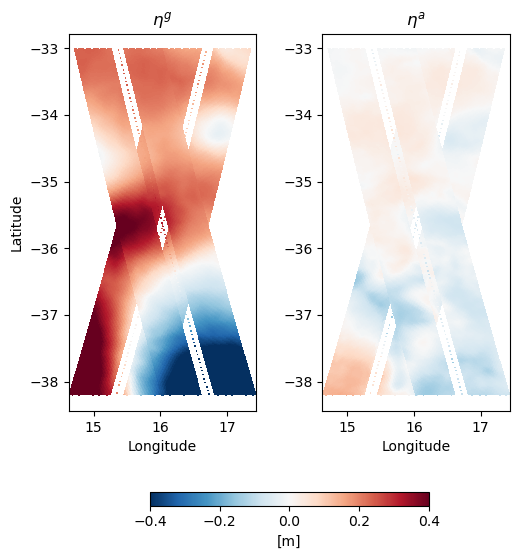

In [54]:
cnum = 20
fig, axes = plt.subplots(figsize=(6,7), nrows=1, ncols=2)
# fig.set_tight_layout(True)
im = axes[0].pcolormesh(g01_exterp.isel(cycle_num=cnum).longitude, g01_exterp.isel(cycle_num=cnum).latitude,
               g01_exterp.isel(cycle_num=cnum),
               vmin=-.4, vmax=.4, cmap="RdBu_r",
               rasterized=True)
axes[0].pcolormesh(g16_exterp.isel(cycle_num=cnum).longitude, g16_exterp.isel(cycle_num=cnum).latitude,
               g16_exterp.isel(cycle_num=cnum),
               vmin=-.4, vmax=.4, cmap="RdBu_r",
               rasterized=True)
axes[1].pcolormesh(a01_exterp.isel(cycle_num=cnum).longitude, a01_exterp.isel(cycle_num=cnum).latitude,
               a01_exterp.isel(cycle_num=cnum),
               vmin=-.4, vmax=.4, cmap="RdBu_r",
               rasterized=True)
axes[1].pcolormesh(a16_exterp.isel(cycle_num=cnum).longitude, a16_exterp.isel(cycle_num=cnum).latitude,
               a16_exterp.isel(cycle_num=cnum),
               vmin=-.4, vmax=.4, cmap="RdBu_r",
               rasterized=True)
axes[0].set_aspect("equal")
axes[1].set_aspect("equal")
axes[0].set_xlabel(r"Longitude")
axes[0].set_ylabel(r"Latitude")
axes[1].set_xlabel(r"Longitude")
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.6)
cbar.set_label(r"[m]")
axes[0].set_title(r"$\eta^g$")
axes[1].set_title(r"$\eta^a$")
plt.savefig(op.join(ddir,"../Figs/ssha-AR.pdf"))

In [55]:
# Fg = xrft.power_spectrum(ar_g.reset_coords(drop=True).chunk({"num_pixels":1}), 
#                          dim=["time"], 
#                          detrend="linear", window="hann",
#                          window_correction=True
#                         )
# Fg = xrft.power_spectrum(Fg.reset_coords(drop=True), 
#                          dim=["num_lines"], 
#                          detrend="linear", window="hann",
#                          window_correction=True
#                         ).mean("num_pixels")
# Fa = xrft.power_spectrum(ar_a.reset_coords(drop=True).chunk({"num_pixels":1}), 
#                          dim=["time"], 
#                          detrend="linear", window="hann",
#                          window_correction=True
#                         )
# Fa = xrft.power_spectrum(Fa.reset_coords(drop=True), 
#                          dim=["num_lines"], 
#                          detrend="linear", window="hann",
#                          window_correction=True
#                         ).mean("num_pixels")
Fg1 = xrft.power_spectrum(ar_g1.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fg1 = xrft.power_spectrum(Fg1.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa1 = xrft.power_spectrum(ar_a1.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fa1 = xrft.power_spectrum(Fa1.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fg6 = xrft.power_spectrum(ar_g6.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fg6 = xrft.power_spectrum(Fg6.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa6 = xrft.power_spectrum(ar_a6.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fa6 = xrft.power_spectrum(Fa6.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa = .5*(Fa1 + Fa6)
Fg = .5*(Fg1 + Fg6)
Fg, Fa

(<xarray.DataArray (freq_time: 105, freq_num_lines: 283)> Size: 238kB
 dask.array<mul, shape=(105, 283), dtype=float64, chunksize=(105, 283), chunktype=numpy.ndarray>
 Coordinates:
   * freq_time       (freq_time) float64 840B -5.732e-06 -5.622e-06 ... 5.732e-06
   * freq_num_lines  (freq_num_lines) float64 2kB -0.0002491 ... 0.0002491,
 <xarray.DataArray (freq_time: 105, freq_num_lines: 283)> Size: 238kB
 dask.array<mul, shape=(105, 283), dtype=float64, chunksize=(105, 283), chunktype=numpy.ndarray>
 Coordinates:
   * freq_time       (freq_time) float64 840B -5.732e-06 -5.622e-06 ... 5.732e-06
   * freq_num_lines  (freq_num_lines) float64 2kB -0.0002491 ... 0.0002491)

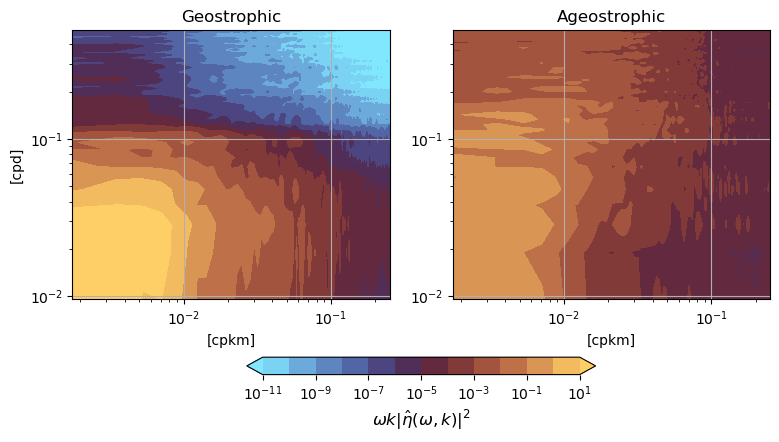

In [56]:
fig, axes = plt.subplots(figsize=(9,5), nrows=1, ncols=2)
# fig.set_tight_layout(True)
im = axes[0].contourf(Fg.freq_num_lines.isel(freq_num_lines=slice(len(Fg.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fg.freq_time.isel(freq_time=slice(len(Fg.freq_time)//2,
                                                 None)).values*86400,
               (Fg.freq_num_lines*Fg.freq_time*Fg
               ).isel(freq_num_lines=slice(len(Fg.freq_num_lines)//2,None),
                      freq_time=slice(len(Fg.freq_time)//2,None)
                     ).values.T*4,
               levels=np.logspace(-11,1,13),
               norm=clr.LogNorm(), cmap="managua_r",
               extend="both",
               rasterized=True
              )
axes[1].contourf(Fa.freq_num_lines.isel(freq_num_lines=slice(len(Fa.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fa.freq_time.isel(freq_time=slice(len(Fa.freq_time)//2,
                                                 None)).values*86400,
               (Fa.freq_num_lines*Fa.freq_time*Fa
               ).isel(freq_num_lines=slice(len(Fa.freq_num_lines)//2,None),
                      freq_time=slice(len(Fa.freq_time)//2,None)
                     ).values.T*4,
               levels=np.logspace(-11,1,13),
               norm=clr.LogNorm(), cmap="managua_r",
                 extend="both",
               rasterized=True
              )
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlim([Fg.freq_num_lines.where(Fg.freq_num_lines>0.).min()*1e3,
              Fg.freq_num_lines.where(Fg.freq_num_lines>0.).max()*1e3])
axes[0].set_ylim([Fg.freq_time.where(Fg.freq_time>0.).min()*86400,
              Fg.freq_time.where(Fg.freq_time>0.).max()*86400])
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlim([Fa.freq_num_lines.where(Fa.freq_num_lines>0.).min()*1e3,
              Fa.freq_num_lines.where(Fa.freq_num_lines>0.).max()*1e3])
axes[1].set_ylim([Fa.freq_time.where(Fa.freq_time>0.).min()*86400,
              Fa.freq_time.where(Fa.freq_time>0.).max()*86400])
axes[0].set_xlabel(r"[cpkm]")
axes[1].set_xlabel(r"[cpkm]")
axes[0].set_ylabel(r"[cpd]")
axes[0].grid(True)
axes[1].grid(True)
axes[0].set_title(r"Geostrophic")
axes[1].set_title(r"Ageostrophic")
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.5)
cbar.set_label(r"$\omega k |\hat{\eta}(\omega,k)|^2$", fontsize=12)
plt.savefig(op.join(ddir,"../Figs/omega-k_AR.pdf"))

In [55]:
dsv1 = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass001/SSVs_SwotDiag.zarr"))
dsv6 = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass016/SSVs_SwotDiag.zarr"))
dsv1r = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass001/SSVs_rawSwotDiag.zarr"))
dsv6r = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass016/SSVs_rawSwotDiag.zarr"))
dsv1, dsv6

(<xarray.Dataset> Size: 3GB
 Dimensions:     (cycle_num: 105, num_lines: 9310, num_pixels: 61)
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 74kB 1 2 3 4 5 6 ... 9854 9855 9856 9857 9858
   * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
     latitude    (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9310, 61), meta=np.ndarray>
     longitude   (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9310, 61), meta=np.ndarray>
 Data variables:
     strain      (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>
     ucg         (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>
     ug          (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>
     vcg         (cycle_num, num_lines, num_pixels) float64 477MB das

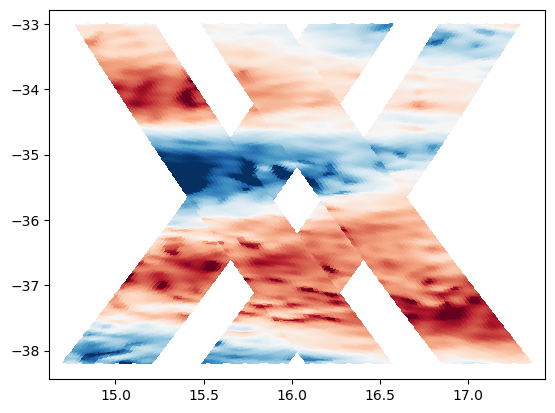

In [26]:
u1 = dsv1.ucg.where(~maskn1,drop=True).where(~masks1,drop=True)
u6 = dsv6.ucg.where(~maskn6,drop=True).where(~masks6,drop=True)

fig, ax = plt.subplots()
ax.pcolormesh(u1.longitude, u1.latitude,
              u1.isel(cycle_num=11),
              vmax=.8, vmin=-.8, cmap="RdBu_r",
              rasterized=True
             )
ax.pcolormesh(u6.longitude, u6.latitude,
              u6.isel(cycle_num=11),
              vmax=.8, vmin=-.8, cmap="RdBu_r",
              rasterized=True
             )

In [56]:
sp1 = np.sqrt(dsv1.ucg**2 + dsv1.vcg**2).where(~maskn1,drop=True).where(~masks1,drop=True)
sp6 = np.sqrt(dsv6.ucg**2 + dsv6.vcg**2).where(~maskn6,drop=True).where(~masks6,drop=True)
v1 = dsv1.vort.where(~maskn1,drop=True).where(~masks1,drop=True)
s1 = dsv1.strain.where(~maskn1,drop=True).where(~masks1,drop=True)
v6 = dsv6.vort.where(~maskn6,drop=True).where(~masks6,drop=True)
s6 = dsv6.strain.where(~maskn6,drop=True).where(~masks6,drop=True)
v1r = dsv1r.vort.where(~maskn1,drop=True
                      ).where(~masks1,drop=True
                             ).isel(num_pixels=slice(4,-4),
                                    num_lines=slice(1,-1)
                                   ).dropna("cycle_num", how="all")
s1r = dsv1r.strain.where(~maskn1,drop=True
                        ).where(~masks1,drop=True
                               ).isel(num_pixels=slice(4,-4),
                                      num_lines=slice(1,-1)
                                     ).dropna("cycle_num", how="all")
v6r = dsv6r.vort.where(~maskn6,drop=True
                      ).where(~masks6,drop=True
                             ).isel(num_pixels=slice(4,-4),
                                    num_lines=slice(1,-1)
                                   ).dropna("cycle_num", how="all")
s6r = dsv6r.strain.where(~maskn6,drop=True
                        ).where(~masks6,drop=True
                               ).isel(num_pixels=slice(4,-4),
                                      num_lines=slice(1,-1)
                                     ).dropna("cycle_num", how="all")
v1, v1r

(<xarray.DataArray 'vort' (cycle_num: 105, num_lines: 308, num_pixels: 61)> Size: 16MB
 dask.array<where, shape=(105, 308, 61), dtype=float64, chunksize=(1, 308, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 2kB 2778 2779 2780 2781 ... 3083 3084 3085
   * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
     latitude    (num_lines, num_pixels) float64 150kB -38.19 -38.19 ... -33.01
     longitude   (num_lines, num_pixels) float64 150kB 14.64 14.66 ... 17.35,
 <xarray.DataArray 'vort' (cycle_num: 95, num_lines: 308, num_pixels: 61)> Size: 14MB
 dask.array<getitem, shape=(95, 308, 61), dtype=float64, chunksize=(1, 308, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 760B 475 478 479 480 481 ... 575 576 577 578
   * num_lines   (num_lines) int64 2kB 2778 2779 2780 2781 ... 3083 3084 3085
   * num_pixels  (num_pixels) int

In [57]:
vort = xr.concat([v1.drop_vars(["cycle_num","num_lines","num_pixels"]),
                  v6.drop_vars(["cycle_num","num_lines","num_pixels"])
                 ], "cycle_num")
strain = xr.concat([s1.drop_vars(["cycle_num","num_lines","num_pixels"]),
                  s6.drop_vars(["cycle_num","num_lines","num_pixels"])
                 ], "cycle_num")
f = gsw.f(vort.latitude)
vort_raw = xr.concat([v1r.drop_vars(["cycle_num","num_lines","num_pixels"]),
                  v6r.drop_vars(["cycle_num","num_lines","num_pixels"])
                 ], "cycle_num")
str_raw = xr.concat([s1r.drop_vars(["cycle_num","num_lines","num_pixels"]),
                  s6r.drop_vars(["cycle_num","num_lines","num_pixels"])
                 ], "cycle_num")
fr = gsw.f(vort_raw.latitude)
vort, strain, f

(<xarray.DataArray 'vort' (cycle_num: 210, num_lines: 308, num_pixels: 61)> Size: 32MB
 dask.array<concatenate, shape=(210, 308, 61), dtype=float64, chunksize=(1, 308, 61), chunktype=numpy.ndarray>
 Coordinates:
     latitude   (cycle_num, num_lines, num_pixels) float64 32MB -38.19 ... -38.43
     longitude  (cycle_num, num_lines, num_pixels) float64 32MB 14.64 ... 16.09
 Dimensions without coordinates: cycle_num, num_lines, num_pixels,
 <xarray.DataArray 'strain' (cycle_num: 210, num_lines: 308, num_pixels: 61)> Size: 32MB
 dask.array<concatenate, shape=(210, 308, 61), dtype=float64, chunksize=(1, 308, 61), chunktype=numpy.ndarray>
 Coordinates:
     latitude   (cycle_num, num_lines, num_pixels) float64 32MB -38.19 ... -38.43
     longitude  (cycle_num, num_lines, num_pixels) float64 32MB 14.64 ... 16.09
 Dimensions without coordinates: cycle_num, num_lines, num_pixels,
 <xarray.DataArray 'latitude' (cycle_num: 210, num_lines: 308, num_pixels: 61)> Size: 32MB
 array([[[-9.01716164e-05

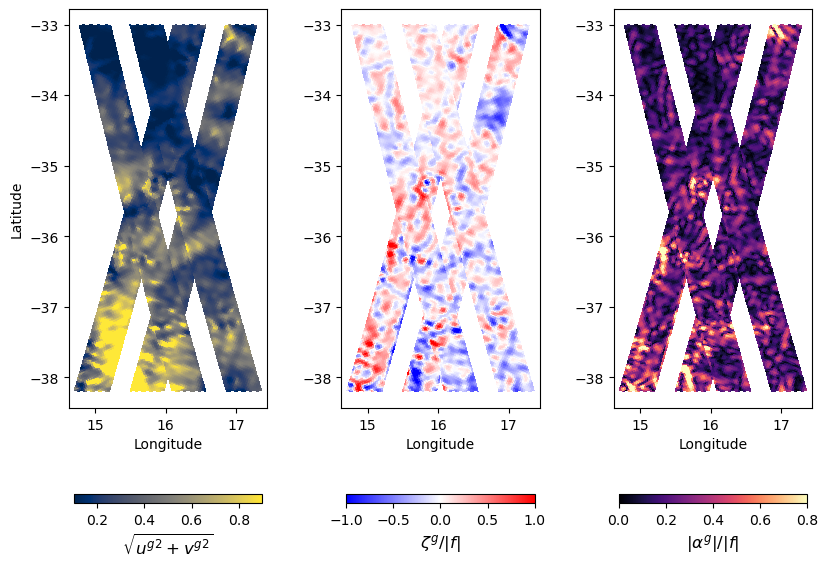

In [50]:
fig, (ax0, ax1,ax2) = plt.subplots(figsize=(9,6), nrows=1, ncols=3)
fig.set_tight_layout(True)
im0 = ax0.pcolormesh(sp1.isel(cycle_num=cnum).longitude, sp1.isel(cycle_num=cnum).latitude,
               sp1.isel(cycle_num=cnum),
               vmin=.1, vmax=.9, cmap="cividis",
               rasterized=True)
ax0.pcolormesh(sp6.isel(cycle_num=cnum).longitude, sp6.isel(cycle_num=cnum).latitude,
               sp6.isel(cycle_num=cnum),
               vmin=.1, vmax=.9, cmap="cividis",
               rasterized=True)
im1 = ax1.pcolormesh(v1.isel(cycle_num=cnum).longitude, v1.isel(cycle_num=cnum).latitude,
               (v1.isel(cycle_num=cnum) 
                / np.abs(gsw.f(v1.isel(cycle_num=cnum).latitude))),
               vmin=-1, vmax=1, cmap="bwr",
               rasterized=True)
ax1.pcolormesh(v6.isel(cycle_num=cnum).longitude, v6.isel(cycle_num=cnum).latitude,
               (v6.isel(cycle_num=cnum) 
                / np.abs(gsw.f(v6.isel(cycle_num=cnum).latitude))),
               vmin=-1, vmax=1, cmap="bwr",
               rasterized=True)
im2 = ax2.pcolormesh(s1.isel(cycle_num=cnum).longitude, s1.isel(cycle_num=cnum).latitude,
               (s1.isel(cycle_num=cnum) 
                / np.abs(gsw.f(s1.isel(cycle_num=cnum).latitude))),
               vmax=.8, vmin=0., cmap="magma",
               rasterized=True)
ax2.pcolormesh(s6.isel(cycle_num=cnum).longitude, s6.isel(cycle_num=cnum).latitude,
               (s6.isel(cycle_num=cnum) 
                / np.abs(gsw.f(s6.isel(cycle_num=cnum).latitude))),
               vmax=.8, vmin=0., cmap="magma",
               rasterized=True)
ax0.set_aspect("equal")
ax1.set_aspect("equal")
ax2.set_aspect("equal")
ax0.set_xlabel(r"Longitude")
ax1.set_xlabel(r"Longitude")
ax0.set_ylabel(r"Latitude")
ax2.set_xlabel(r"Longitude")
cbar0 = fig.colorbar(im0, ax=ax0, orientation="horizontal", shrink=.6)
cbar1 = fig.colorbar(im1, ax=ax1, orientation="horizontal", shrink=.6)
cbar2 = fig.colorbar(im2, ax=ax2, orientation="horizontal", shrink=.6)
cbar0.set_label(r"$\sqrt{{u^g}^2 + {v^g}^2}$", fontsize=12)
cbar1.set_label(r"$\zeta^g/|f|$", fontsize=12)
cbar2.set_label(r"$|\alpha^g|/|f|$", fontsize=12)
plt.savefig(op.join(ddir,"../Figs/vort-strain-AR.pdf"))

In [58]:
vbins = np.linspace(-3e0,3e0,60)
sbins = np.linspace(0,3e0,30)
hist_c = xhist((strain / np.abs(f)).rename('strain'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               (vort / np.abs(f)).rename('vort'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               bins=[sbins, vbins], density=True
              ).compute()
hist_r = xhist((str_raw / np.abs(fr)).rename('strain'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               (vort_raw / np.abs(fr)).rename('vort'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               bins=[sbins, vbins], density=True
              ).compute()

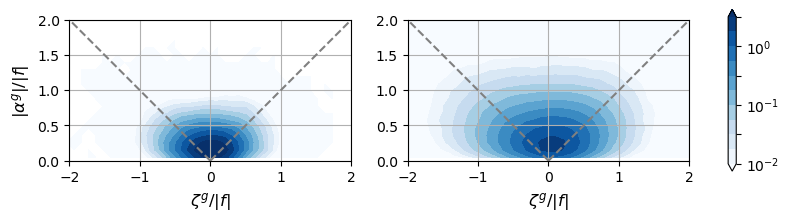

In [59]:
fig, axes = plt.subplots(figsize=(10,3), nrows=1, ncols=2)
# fig.set_tight_layout(True)

im = axes[0].contourf(hist_c.vort_bin,
                 hist_c.strain_bin,
                 hist_c, 
                 cmap='Blues', locator=ticker.LogLocator(), 
                 norm=clr.LogNorm(), levels=np.logspace(-2,.5,11),
                 extend='both'
#                       rasterized=True
               )
axes[1].contourf(hist_r.vort_bin,
                 hist_r.strain_bin,
                 hist_r, 
                 cmap='Blues', locator=ticker.LogLocator(), 
                 norm=clr.LogNorm(), levels=np.logspace(-2,.5,11),
                 extend='both'
#                       rasterized=True
               )

# for c in im.collections:
#     c.set_rasterized(True)

axes[0].plot(np.linspace(0,3,5),np.linspace(0,3,5),c='grey',ls='--')
axes[0].plot(np.linspace(-3,0,5),np.linspace(3,0,5),c='grey',ls='--')
axes[1].plot(np.linspace(0,3,5),np.linspace(0,3,5),c='grey',ls='--')
axes[1].plot(np.linspace(-3,0,5),np.linspace(3,0,5),c='grey',ls='--')

axes[0].set_xlim([-2,2])
axes[0].set_ylim([0,2])
axes[1].set_xlim([-2,2])
axes[1].set_ylim([0,2])

axes[0].set_xlabel(r"$\zeta^g/|f|$", fontsize=12)
axes[1].set_xlabel(r"$\zeta^g/|f|$", fontsize=12)
axes[0].set_ylabel(r"$|\alpha^g|/|f|$", fontsize=12)

axes[0].grid(True)
axes[0].set_aspect('equal')
axes[1].grid(True)
axes[1].set_aspect('equal')

# fig.subplots_adjust(hspace=.06, wspace=.12)
# cbar = fig.colorbar(im, orientation='horizontal', ax=axes, shrink=.4, 
#                     ticks=[1e-4,1e-3,1e-2,1e-1,1e0])
cbar = fig.colorbar(im, ax=axes, shrink=.7)
# cbar.set_ticks([1e-2,1e-1,0,1])

plt.savefig(op.join(ddir,"../Figs/vort-strain-ARjointPDF.pdf"))

# Kuroshio

In [30]:
ds04 = xr.open_zarr(op.join(ddir,"SWOT_no_IT/CalVal_pass%03d_v2.0.1.zarr"
                            % 4))
ds04.coords["num_lines"] = ("num_lines",range(len(ds04.num_lines)))
ds04.coords["num_pixels"] = ("num_pixels",range(len(ds04.num_pixels)))

ds19 = xr.open_zarr(op.join(ddir,"SWOT_no_IT/CalVal_pass%03d_v2.0.1.zarr"
                            % 19))
ds19.coords["num_lines"] = ("num_lines",range(len(ds19.num_lines)))
ds19.coords["num_pixels"] = ("num_pixels",range(len(ds19.num_pixels)))
ds04,ds19

(<xarray.Dataset> Size: 582MB
 Dimensions:       (cycle_num: 105, num_lines: 9860, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 79kB 0 1 2 3 4 ... 9855 9856 9857 9858 9859
   * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 68
     latitude      (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9860, 69), meta=np.ndarray>
     longitude     (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9860, 69), meta=np.ndarray>
 Data variables:
     ssha_detided  (cycle_num, num_lines, num_pixels) float64 571MB dask.array<chunksize=(1, 9860, 69), meta=np.ndarray>,
 <xarray.Dataset> Size: 582MB
 Dimensions:       (cycle_num: 105, num_lines: 9860, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 79kB 0 1 2 3 4 ... 9855 9856 9857 9858 9859
   * num_pixels  

In [31]:
maskn4 = xr.DataArray(ds04.latitude.where(ds04.latitude<38.4).to_masked_array().mask,
                     dims=ds04.latitude.dims,
                     coords=ds04.latitude.coords
                    )
masks4 = xr.DataArray(ds04.latitude.where(ds04.latitude>33).to_masked_array().mask,
                     dims=ds04.latitude.dims,
                     coords=ds04.latitude.coords
                    )
xo04 = ds04.where(~maskn4,drop=True).where(~masks4,drop=True)

maskn9 = xr.DataArray(ds19.latitude.where(ds19.latitude<38.4).to_masked_array().mask,
                     dims=ds19.latitude.dims,
                     coords=ds19.latitude.coords
                    )
masks9 = xr.DataArray(ds19.latitude.where(ds19.latitude>33).to_masked_array().mask,
                     dims=ds19.latitude.dims,
                     coords=ds19.latitude.coords
                    )
xo19 = ds19.where(~maskn9,drop=True).where(~masks9,drop=True)
xo04, xo19

(<xarray.Dataset> Size: 19MB
 Dimensions:       (cycle_num: 105, num_lines: 321, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 3kB 2766 2767 2768 2769 ... 3084 3085 3086
   * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 68
     latitude      (num_lines, num_pixels) float64 177kB 38.65 38.65 ... 32.76
     longitude     (num_lines, num_pixels) float64 177kB 157.4 157.4 ... 157.5
 Data variables:
     ssha_detided  (cycle_num, num_lines, num_pixels) float64 19MB dask.array<chunksize=(1, 321, 69), meta=np.ndarray>,
 <xarray.Dataset> Size: 19MB
 Dimensions:       (cycle_num: 105, num_lines: 321, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 3kB 6775 6776 6777 6778 ... 7093 7094 7095
   * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 6

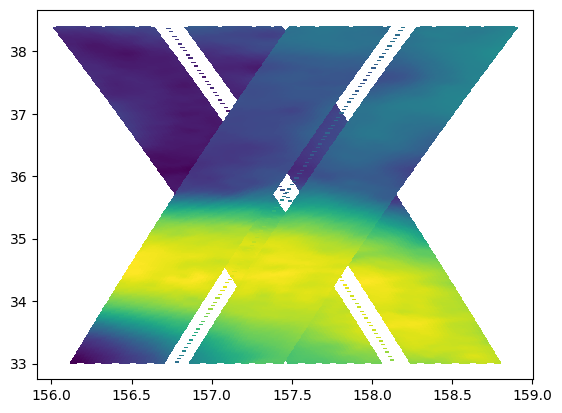

In [32]:
fig, ax = plt.subplots()
ax.pcolormesh(xo04.longitude, xo04.latitude,
              xo04.ssha_detided.isel(cycle_num=10),
              rasterized=True
             )
ax.pcolormesh(xo19.longitude, xo19.latitude,
              xo19.ssha_detided.isel(cycle_num=10),
              rasterized=True
             )

In [33]:
inp = 3

mask04 = xr.DataArray(xo04.ssha_detided.to_masked_array().mask.mean(axis=0), 
                     dims=xo04.ssha_detided.isel(cycle_num=0).dims, 
                     coords=xo04.ssha_detided.isel(cycle_num=0).coords
                    )
mm04 = xr.DataArray(mask04.where(mask04<.5
                              ).to_masked_array().mask,
                   dims=xo04.ssha_detided.isel(cycle_num=0).dims, 
                   coords=xo04.ssha_detided.isel(cycle_num=0).coords
                  ).isel(num_pixels=slice(inp,-inp))
mask19 = xr.DataArray(xo19.ssha_detided.to_masked_array().mask.mean(axis=0), 
                     dims=xo19.ssha_detided.isel(cycle_num=0).dims, 
                     coords=xo19.ssha_detided.isel(cycle_num=0).coords
                    )
mm19 = xr.DataArray(mask19.where(mask19<.5
                              ).to_masked_array().mask,
                   dims=xo19.ssha_detided.isel(cycle_num=0).dims, 
                   coords=xo19.ssha_detided.isel(cycle_num=0).coords
                  ).isel(num_pixels=slice(inp,-inp))
mm04, mm19

(<xarray.DataArray (num_lines: 321, num_pixels: 63)> Size: 20kB
 array([[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ..., False, False,  True],
        [ True,  True,  True, ..., False, False,  True],
        ...,
        [ True, False, False, ...,  True,  True,  True],
        [ True, False, False, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]], shape=(321, 63))
 Coordinates:
   * num_lines   (num_lines) int64 3kB 2766 2767 2768 2769 ... 3084 3085 3086
   * num_pixels  (num_pixels) int64 504B 3 4 5 6 7 8 9 ... 59 60 61 62 63 64 65
     cycle_num   int64 8B 474
     latitude    (num_lines, num_pixels) float64 162kB 38.64 38.64 ... 32.77
     longitude   (num_lines, num_pixels) float64 162kB 157.4 157.4 ... 157.5,
 <xarray.DataArray (num_lines: 321, num_pixels: 63)> Size: 20kB
 array([[ True,  True,  True, ...,  True,  True,  True],
        [ True, False, False, ...,  True,  True,  True],
        [ True, False, False

In [34]:
low04 = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass%03d/SSHa.zarr" 
                               % 4)
                      ).ssha.where(~maskn4,drop=True).where(~masks4,drop=True)
low19 = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass%03d/SSHa.zarr" 
                               % 19)
                      ).ssha.where(~maskn9,drop=True).where(~masks9,drop=True)
low04, low19

(<xarray.DataArray 'ssha' (cycle_num: 105, num_lines: 319, num_pixels: 61)> Size: 16MB
 dask.array<where, shape=(105, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 3kB 2767 2768 2769 2770 ... 3083 3084 3085
   * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
     latitude    (num_lines, num_pixels) float64 156kB 38.62 38.62 ... 32.79
     longitude   (num_lines, num_pixels) float64 156kB 157.4 157.3 ... 157.5,
 <xarray.DataArray 'ssha' (cycle_num: 105, num_lines: 319, num_pixels: 61)> Size: 16MB
 dask.array<where, shape=(105, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 3kB 6776 6777 6778 6779 ... 7092 7093 7094
   * num_pixels  (num_pixels) int64 

In [35]:
r_ref4 = (~mm04).sum() / np.prod(mm04.shape)
r_ref9 = (~mm19).sum() / np.prod(mm19.shape)
r_ref9

<xarray.DataArray ()> Size: 8B
array(0.80724917)
Coordinates:
    cycle_num  int64 8B 474

In [36]:
ageo = (1e-2*ds04.ssha_detided
        - low04
       )
ic = 0
for cc in ageo.cycle_num:

    sshg = low04.sel(cycle_num=cc)
    ssha = ageo.sel(cycle_num=cc)
    
    array = ssha.to_masked_array()
    mask = ~array.mask
    ratio = mask.sum() / np.prod(mask.shape)
    if ic == 0:
        r04 = xr.DataArray(np.array([ratio]), 
                           dims='cycle_num', 
                           coords={'cycle_num':np.array([cc.values,])}
                          )
    else:
        r04 = xr.concat([r04, xr.DataArray(np.array([ratio]), 
                               dims='cycle_num', 
                               coords={'cycle_num':np.array([cc.values,])}
                                          )
                        ], 'cycle_num')
    if ratio > .7*r_ref4:
        if ic == 0:
            a04 = ssha
        else:
            try:
                a04 = xr.concat([a04, ssha], 'cycle_num')
            except:
                pass
        ic += 1
    # else:
    #     ssha.plot(rasterized=True)
    #     plt.show()
    del ssha, mask, array

a04.coords["cycle_num"] = ("cycle_num",
                           r04.where(r04>0.7*r_ref4, drop=True).cycle_num.data
                          )

dsa04 = a04.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsa04.coords["y"] = ("y",range(len(dsa04.y)))
dsa04.coords["x"] = ("x",range(len(dsa04.x)))
if not dsa04.rio.crs:
    dsa04 = dsa04.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsa04.ssha.rio.nodata is None:
    dsa04["ssha"] = dsa04.ssha.rio.write_nodata(np.nan)
_a04_exterp = dsa04.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_a04_interp = _a04_exterp.interp(cycle_num=ds04.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
a04_exterp = _a04_exterp.where(mm04.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds04.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsa04.close()

dsg04 = low04.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsg04.coords["y"] = ("y",range(len(dsg04.y)))
dsg04.coords["x"] = ("x",range(len(dsg04.x)))
if not dsg04.rio.crs:
    dsg04 = dsg04.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsg04.ssha.rio.nodata is None:
    dsg04["ssha"] = dsg04.ssha.rio.write_nodata(np.nan)
_g04_exterp = dsg04.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_g04_interp = _g04_exterp.interp(cycle_num=ds04.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
g04_exterp = _g04_exterp.where(mm04.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds04.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsg04.close()

In [37]:
ageo = (1e-2*ds19.ssha_detided
        - low19
       )
ic = 0
for cc in ageo.cycle_num:

    sshg = low19.sel(cycle_num=cc)
    ssha = ageo.sel(cycle_num=cc)
    
    array = ssha.to_masked_array()
    mask = ~array.mask
    ratio = mask.sum() / np.prod(mask.shape)
    if ic == 0:
        r19 = xr.DataArray(np.array([ratio]), 
                           dims='cycle_num', 
                           coords={'cycle_num':np.array([cc.values,])}
                          )
    else:
        r19 = xr.concat([r19, xr.DataArray(np.array([ratio]), 
                               dims='cycle_num', 
                               coords={'cycle_num':np.array([cc.values,])}
                                          )
                        ], 'cycle_num')
    if ratio > .7*r_ref9:
        if ic == 0:
            a19 = ssha
        else:
            try:
                a19 = xr.concat([a19, ssha], 'cycle_num')
            except:
                pass
        ic += 1
    # else:
    #     ssha.plot(rasterized=True)
    #     plt.show()
    del ssha, mask, array

a19.coords["cycle_num"] = ("cycle_num",
                           r19.where(r19>0.7*r_ref9, drop=True).cycle_num.data
                          )

dsa19 = a19.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsa19.coords["y"] = ("y",range(len(dsa19.y)))
dsa19.coords["x"] = ("x",range(len(dsa19.x)))
if not dsa19.rio.crs:
    dsa19 = dsa19.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsa19.ssha.rio.nodata is None:
    dsa19["ssha"] = dsa19.ssha.rio.write_nodata(np.nan)
_a19_exterp = dsa19.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_a19_interp = _a19_exterp.interp(cycle_num=ds19.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
a19_exterp = _a19_exterp.where(mm19.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds19.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsa19.close()

dsg19 = low19.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsg19.coords["y"] = ("y",range(len(dsg19.y)))
dsg19.coords["x"] = ("x",range(len(dsg19.x)))
if not dsg19.rio.crs:
    dsg19 = dsg19.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsg19.ssha.rio.nodata is None:
    dsg19["ssha"] = dsg19.ssha.rio.write_nodata(np.nan)
_g19_exterp = dsg19.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_g19_interp = _g19_exterp.interp(cycle_num=ds19.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
g19_exterp = _g19_exterp.where(mm19.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds19.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsg19.close()

In [38]:
for cc in low04.cycle_num:
    if cc == low04.cycle_num[0]:
        ar_g4 = g04_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        ar_a4 = a04_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])

        ar_g9 = g19_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        ar_a9 = a19_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
    else:
        ar_g4 = xr.concat([ar_g4, 
                          g04_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_a4 = xr.concat([ar_a4, 
                          a04_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_g9 = xr.concat([ar_g9, 
                          g19_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_a9 = xr.concat([ar_a9, 
                          a19_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")

ar_g4.coords["time"] = ("time",np.arange(len(ar_g4.time))*24*60.*60)
ar_a4.coords["time"] = ("time",np.arange(len(ar_a4.time))*24*60.*60)
ar_g9.coords["time"] = ("time",np.arange(len(ar_g9.time))*24*60.*60)
ar_a9.coords["time"] = ("time",np.arange(len(ar_a9.time))*24*60.*60)
ar_g4.coords["num_lines"] = ("num_lines",np.arange(len(ar_g4.num_lines))*2e3)
ar_a4.coords["num_lines"] = ("num_lines",np.arange(len(ar_a4.num_lines))*2e3)
ar_g9.coords["num_lines"] = ("num_lines",np.arange(len(ar_g9.num_lines))*2e3)
ar_a9.coords["num_lines"] = ("num_lines",np.arange(len(ar_a9.num_lines))*2e3)

ar_g4, ar_a9

(<xarray.DataArray 'ssha' (time: 105, num_lines: 294, num_pixels: 2)> Size: 494kB
 array([[[-0.08128967, -0.08233746],
         [-0.08241828, -0.08140355],
         [-0.0841654 , -0.08006125],
         ...,
         [ 0.31831134,  0.27476109],
         [ 0.31446492,  0.27228893],
         [ 0.3103847 ,  0.2697889 ]],
 
        [[-0.08770048, -0.08329737],
         [-0.08900584, -0.08143524],
         [-0.09075608, -0.07931117],
         ...,
         [ 0.32754773,  0.27508456],
         [ 0.32390835,  0.27274461],
         [ 0.31993306,  0.27037116]],
 
        [[-0.09231995, -0.08584548],
         [-0.09394   , -0.08327787],
         [-0.09577118, -0.0805897 ],
         ...,
 ...
         ...,
         [ 0.41027382,  0.30607276],
         [ 0.40763841,  0.30465487],
         [ 0.40374359,  0.3030552 ]],
 
        [[-0.06868749,  0.20889942],
         [-0.06901743,  0.21695506],
         [-0.0697861 ,  0.22479929],
         ...,
         [ 0.40646136,  0.30201013],
         [ 0.4040297

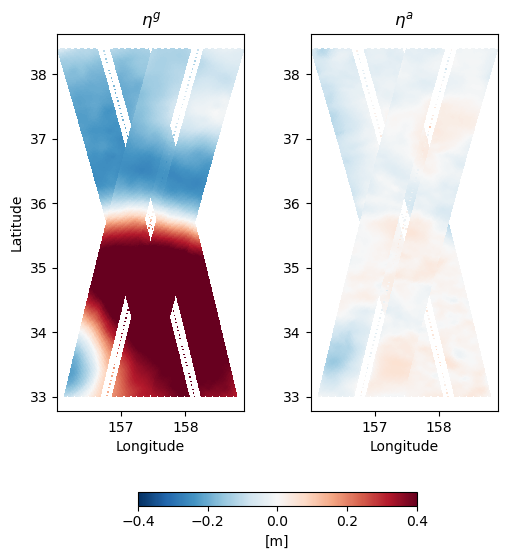

In [39]:
cnum = 20
fig, axes = plt.subplots(figsize=(6,7), nrows=1, ncols=2)
# fig.set_tight_layout(True)
im = axes[0].pcolormesh(g04_exterp.isel(cycle_num=cnum).longitude, g04_exterp.isel(cycle_num=cnum).latitude,
               g04_exterp.isel(cycle_num=cnum),
               vmin=-.4, vmax=.4, cmap="RdBu_r",
               rasterized=True)
axes[0].pcolormesh(g19_exterp.isel(cycle_num=cnum).longitude, g19_exterp.isel(cycle_num=cnum).latitude,
               g19_exterp.isel(cycle_num=cnum),
               vmin=-.4, vmax=.4, cmap="RdBu_r",
               rasterized=True)
axes[1].pcolormesh(a04_exterp.isel(cycle_num=cnum).longitude, a04_exterp.isel(cycle_num=cnum).latitude,
               a04_exterp.isel(cycle_num=cnum),
               vmin=-.4, vmax=.4, cmap="RdBu_r",
               rasterized=True)
axes[1].pcolormesh(a19_exterp.isel(cycle_num=cnum).longitude, a19_exterp.isel(cycle_num=cnum).latitude,
               a19_exterp.isel(cycle_num=cnum),
               vmin=-.4, vmax=.4, cmap="RdBu_r",
               rasterized=True)
axes[0].set_aspect("equal")
axes[1].set_aspect("equal")
axes[0].set_xlabel(r"Longitude")
axes[0].set_ylabel(r"Latitude")
axes[1].set_xlabel(r"Longitude")
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.6)
cbar.set_label(r"[m]")
axes[0].set_title(r"$\eta^g$")
axes[1].set_title(r"$\eta^a$")
plt.savefig(op.join(ddir,"../Figs/ssha-Kx.pdf"))

In [40]:
Fg4 = xrft.power_spectrum(ar_g4.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fg4 = xrft.power_spectrum(Fg4.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa4 = xrft.power_spectrum(ar_a4.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fa4 = xrft.power_spectrum(Fa4.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fg9 = xrft.power_spectrum(ar_g9.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fg9 = xrft.power_spectrum(Fg9.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa9 = xrft.power_spectrum(ar_a9.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fa9 = xrft.power_spectrum(Fa9.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa = .5*(Fa4 + Fa9)
Fg = .5*(Fg4 + Fg9)
Fg, Fa

(<xarray.DataArray (freq_time: 105, freq_num_lines: 294)> Size: 247kB
 dask.array<mul, shape=(105, 294), dtype=float64, chunksize=(105, 294), chunktype=numpy.ndarray>
 Coordinates:
   * freq_time       (freq_time) float64 840B -5.732e-06 -5.622e-06 ... 5.732e-06
   * freq_num_lines  (freq_num_lines) float64 2kB -0.00025 ... 0.0002483,
 <xarray.DataArray (freq_time: 105, freq_num_lines: 294)> Size: 247kB
 dask.array<mul, shape=(105, 294), dtype=float64, chunksize=(105, 294), chunktype=numpy.ndarray>
 Coordinates:
   * freq_time       (freq_time) float64 840B -5.732e-06 -5.622e-06 ... 5.732e-06
   * freq_num_lines  (freq_num_lines) float64 2kB -0.00025 ... 0.0002483)

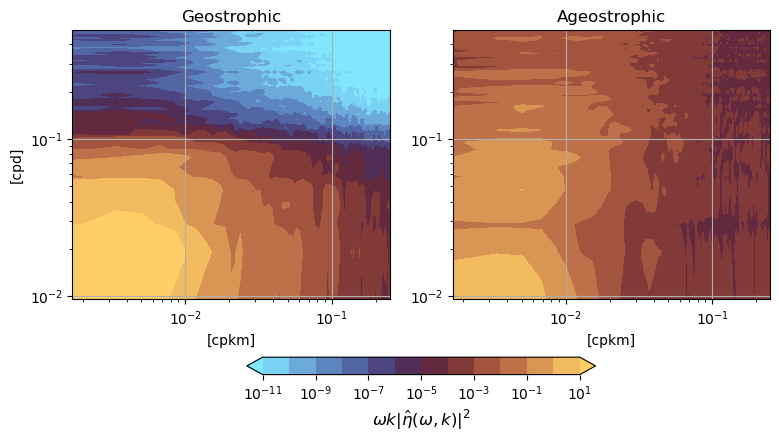

In [41]:
fig, axes = plt.subplots(figsize=(9,5), nrows=1, ncols=2)
# fig.set_tight_layout(True)
im = axes[0].contourf(Fg.freq_num_lines.isel(freq_num_lines=slice(len(Fg.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fg.freq_time.isel(freq_time=slice(len(Fg.freq_time)//2,
                                                 None)).values*86400,
               (Fg.freq_num_lines*Fg.freq_time*Fg
               ).isel(freq_num_lines=slice(len(Fg.freq_num_lines)//2,None),
                      freq_time=slice(len(Fg.freq_time)//2,None)
                     ).values.T*4,
               levels=np.logspace(-11,1,13),
               norm=clr.LogNorm(), cmap="managua_r",
               extend="both",
               rasterized=True
              )
axes[1].contourf(Fa.freq_num_lines.isel(freq_num_lines=slice(len(Fa.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fa.freq_time.isel(freq_time=slice(len(Fa.freq_time)//2,
                                                 None)).values*86400,
               (Fa.freq_num_lines*Fa.freq_time*Fa
               ).isel(freq_num_lines=slice(len(Fa.freq_num_lines)//2,None),
                      freq_time=slice(len(Fa.freq_time)//2,None)
                     ).values.T*4,
               levels=np.logspace(-11,1,13),
               norm=clr.LogNorm(), cmap="managua_r",
                 extend="both",
               rasterized=True
              )
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlim([Fg.freq_num_lines.where(Fg.freq_num_lines>0.).min()*1e3,
              Fg.freq_num_lines.where(Fg.freq_num_lines>0.).max()*1e3])
axes[0].set_ylim([Fg.freq_time.where(Fg.freq_time>0.).min()*86400,
              Fg.freq_time.where(Fg.freq_time>0.).max()*86400])
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlim([Fa.freq_num_lines.where(Fa.freq_num_lines>0.).min()*1e3,
              Fa.freq_num_lines.where(Fa.freq_num_lines>0.).max()*1e3])
axes[1].set_ylim([Fa.freq_time.where(Fa.freq_time>0.).min()*86400,
              Fa.freq_time.where(Fa.freq_time>0.).max()*86400])
axes[0].set_xlabel(r"[cpkm]")
axes[1].set_xlabel(r"[cpkm]")
axes[0].set_ylabel(r"[cpd]")
axes[0].grid(True)
axes[1].grid(True)
axes[0].set_title(r"Geostrophic")
axes[1].set_title(r"Ageostrophic")
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.5)
cbar.set_label(r"$\omega k |\hat{\eta}(\omega,k)|^2$", fontsize=12)
plt.savefig(op.join(ddir,"../Figs/omega-k_Kx.pdf"))

In [82]:
dsv4 = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass004/SSVs_SwotDiag.zarr"))
dsv9 = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass019/SSVs_SwotDiag.zarr"))
dsv4r = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass004/SSVs_rawSwotDiag.zarr"))
dsv9r = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass019/SSVs_rawSwotDiag.zarr"))
dsv4, dsv9

(<xarray.Dataset> Size: 3GB
 Dimensions:     (cycle_num: 105, num_lines: 9310, num_pixels: 61)
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 74kB 1 2 3 4 5 6 ... 9854 9855 9856 9857 9858
   * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
     latitude    (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9310, 61), meta=np.ndarray>
     longitude   (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9310, 61), meta=np.ndarray>
 Data variables:
     strain      (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>
     ucg         (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>
     ug          (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>
     vcg         (cycle_num, num_lines, num_pixels) float64 477MB das

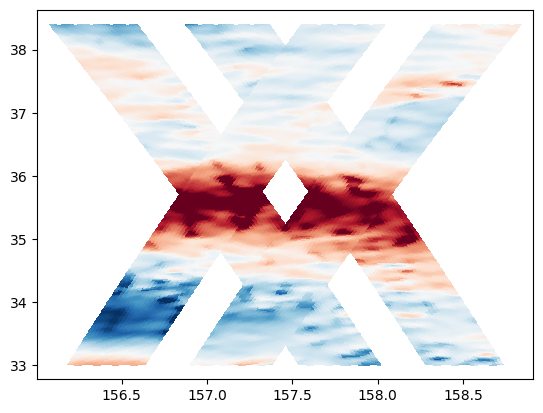

In [83]:
u4 = dsv4.ucg.where(~maskn4,drop=True).where(~masks4,drop=True)
u9 = dsv9.ucg.where(~maskn9,drop=True).where(~masks9,drop=True)

fig, ax = plt.subplots()
ax.pcolormesh(u4.longitude, u4.latitude,
              u4.isel(cycle_num=11),
              vmax=.8, vmin=-.8, cmap="RdBu_r",
              rasterized=True
             )
ax.pcolormesh(u9.longitude, u9.latitude,
              u9.isel(cycle_num=11),
              vmax=.8, vmin=-.8, cmap="RdBu_r",
              rasterized=True
             )

In [88]:
sp4 = np.sqrt(dsv4.ucg**2 + dsv4.vcg**2).where(~maskn4,drop=True).where(~masks4,drop=True)
sp9 = np.sqrt(dsv9.ucg**2 + dsv9.vcg**2).where(~maskn9,drop=True).where(~masks9,drop=True)
v4 = dsv4.vort.where(~maskn4,drop=True).where(~masks4,drop=True)
s4 = dsv4.strain.where(~maskn4,drop=True).where(~masks4,drop=True)
v9 = dsv9.vort.where(~maskn9,drop=True).where(~masks9,drop=True)
s9 = dsv9.strain.where(~maskn9,drop=True).where(~masks9,drop=True)
v4r = dsv4r.vort.where(~maskn4,drop=True
                      ).where(~masks4,drop=True
                             ).isel(num_pixels=slice(4,-4),
                                    num_lines=slice(1,-1)
                                   ).dropna("cycle_num", how="all")
s4r = dsv4r.strain.where(~maskn4,drop=True
                        ).where(~masks4,drop=True
                               ).isel(num_pixels=slice(4,-4),
                                      num_lines=slice(1,-1)
                                     ).dropna("cycle_num", how="all")
v9r = dsv9r.vort.where(~maskn9,drop=True
                      ).where(~masks9,drop=True
                             ).isel(num_pixels=slice(4,-4),
                                    num_lines=slice(1,-1)
                                   ).dropna("cycle_num", how="all")
s9r = dsv9r.strain.where(~maskn9,drop=True
                        ).where(~masks9,drop=True
                               ).isel(num_pixels=slice(4,-4),
                                      num_lines=slice(1,-1)
                                     ).dropna("cycle_num", how="all")
v4, v4r

(<xarray.DataArray 'vort' (cycle_num: 105, num_lines: 319, num_pixels: 61)> Size: 16MB
 dask.array<where, shape=(105, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 3kB 2767 2768 2769 2770 ... 3083 3084 3085
   * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
     latitude    (num_lines, num_pixels) float64 156kB 38.62 38.62 ... 32.79
     longitude   (num_lines, num_pixels) float64 156kB 157.4 157.3 ... 157.5,
 <xarray.DataArray 'vort' (cycle_num: 94, num_lines: 319, num_pixels: 61)> Size: 15MB
 dask.array<getitem, shape=(94, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 752B 475 478 479 480 481 ... 575 576 577 578
   * num_lines   (num_lines) int64 3kB 2767 2768 2769 2770 ... 3083 3084 3085
   * num_pixels  (num_pixels) int64 

In [89]:
vort = xr.concat([v4.drop_vars(["cycle_num","num_lines","num_pixels"]),
                  v9.drop_vars(["cycle_num","num_lines","num_pixels"])
                 ], "cycle_num")
strain = xr.concat([s4.drop_vars(["cycle_num","num_lines","num_pixels"]),
                  s9.drop_vars(["cycle_num","num_lines","num_pixels"])
                 ], "cycle_num")
f = gsw.f(vort.latitude)
vort_raw = xr.concat([v4r.drop_vars(["cycle_num","num_lines","num_pixels"]),
                  v9r.drop_vars(["cycle_num","num_lines","num_pixels"])
                 ], "cycle_num")
str_raw = xr.concat([s4r.drop_vars(["cycle_num","num_lines","num_pixels"]),
                  s9r.drop_vars(["cycle_num","num_lines","num_pixels"])
                 ], "cycle_num")
fr = gsw.f(vort_raw.latitude)
vort, strain, f

(<xarray.DataArray 'vort' (cycle_num: 210, num_lines: 319, num_pixels: 61)> Size: 33MB
 dask.array<concatenate, shape=(210, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
     latitude   (cycle_num, num_lines, num_pixels) float64 33MB 38.62 ... 38.38
     longitude  (cycle_num, num_lines, num_pixels) float64 33MB 157.4 ... 158.9
 Dimensions without coordinates: cycle_num, num_lines, num_pixels,
 <xarray.DataArray 'strain' (cycle_num: 210, num_lines: 319, num_pixels: 61)> Size: 33MB
 dask.array<concatenate, shape=(210, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
     latitude   (cycle_num, num_lines, num_pixels) float64 33MB 38.62 ... 38.38
     longitude  (cycle_num, num_lines, num_pixels) float64 33MB 157.4 ... 158.9
 Dimensions without coordinates: cycle_num, num_lines, num_pixels,
 <xarray.DataArray 'latitude' (cycle_num: 210, num_lines: 319, num_pixels: 61)> Size: 33MB
 array([[[9.10315109e-05, 9.1

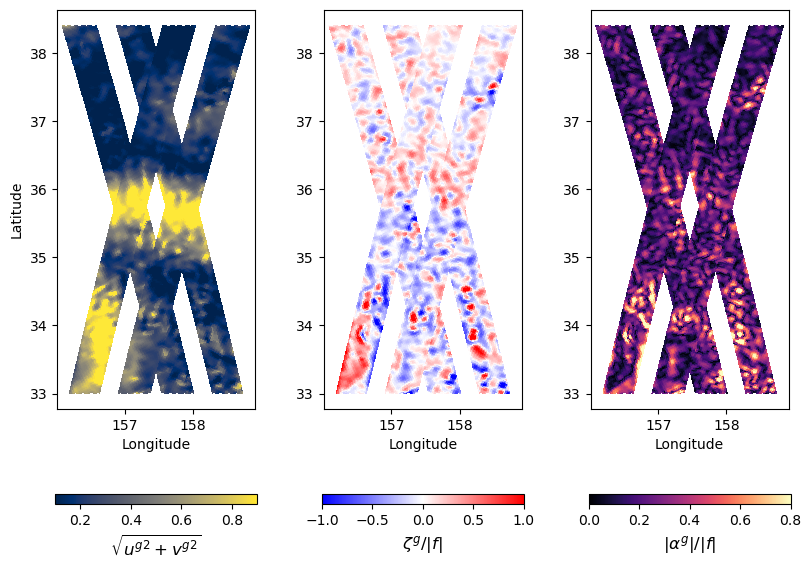

In [90]:
fig, (ax0, ax1,ax2) = plt.subplots(figsize=(9,6), nrows=1, ncols=3)
fig.set_tight_layout(True)
im0 = ax0.pcolormesh(sp4.isel(cycle_num=cnum).longitude, sp4.isel(cycle_num=cnum).latitude,
               sp4.isel(cycle_num=cnum),
               vmin=.1, vmax=.9, cmap="cividis",
               rasterized=True)
ax0.pcolormesh(sp9.isel(cycle_num=cnum).longitude, sp9.isel(cycle_num=cnum).latitude,
               sp9.isel(cycle_num=cnum),
               vmin=.1, vmax=.9, cmap="cividis",
               rasterized=True)
im1 = ax1.pcolormesh(v4.isel(cycle_num=cnum).longitude, v4.isel(cycle_num=cnum).latitude,
               (v4.isel(cycle_num=cnum) 
                / np.abs(gsw.f(v4.isel(cycle_num=cnum).latitude))),
               vmin=-1, vmax=1, cmap="bwr",
               rasterized=True)
ax1.pcolormesh(v9.isel(cycle_num=cnum).longitude, v9.isel(cycle_num=cnum).latitude,
               (v9.isel(cycle_num=cnum) 
                / np.abs(gsw.f(v9.isel(cycle_num=cnum).latitude))),
               vmin=-1, vmax=1, cmap="bwr",
               rasterized=True)
im2 = ax2.pcolormesh(s4.isel(cycle_num=cnum).longitude, s4.isel(cycle_num=cnum).latitude,
               (s4.isel(cycle_num=cnum) 
                / np.abs(gsw.f(s4.isel(cycle_num=cnum).latitude))),
               vmax=.8, vmin=0., cmap="magma",
               rasterized=True)
ax2.pcolormesh(s9.isel(cycle_num=cnum).longitude, s9.isel(cycle_num=cnum).latitude,
               (s9.isel(cycle_num=cnum) 
                / np.abs(gsw.f(s9.isel(cycle_num=cnum).latitude))),
               vmax=.8, vmin=0., cmap="magma",
               rasterized=True)
ax0.set_aspect("equal")
ax1.set_aspect("equal")
ax2.set_aspect("equal")
ax0.set_xlabel(r"Longitude")
ax1.set_xlabel(r"Longitude")
ax0.set_ylabel(r"Latitude")
ax2.set_xlabel(r"Longitude")
cbar0 = fig.colorbar(im0, ax=ax0, orientation="horizontal", shrink=.6)
cbar1 = fig.colorbar(im1, ax=ax1, orientation="horizontal", shrink=.6)
cbar2 = fig.colorbar(im2, ax=ax2, orientation="horizontal", shrink=.6)
cbar0.set_label(r"$\sqrt{{u^g}^2 + {v^g}^2}$", fontsize=12)
cbar1.set_label(r"$\zeta^g/|f|$", fontsize=12)
cbar2.set_label(r"$|\alpha^g|/|f|$", fontsize=12)
plt.savefig(op.join(ddir,"../Figs/vort-strain-Kx.pdf"))

In [91]:
vbins = np.linspace(-3e0,3e0,60)
sbins = np.linspace(0,3e0,30)
hist_c = xhist((strain / np.abs(f)).rename('strain'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               (vort / np.abs(f)).rename('vort'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               bins=[sbins, vbins], density=True
              ).compute()
hist_r = xhist((str_raw / np.abs(fr)).rename('strain'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               (vort_raw / np.abs(fr)).rename('vort'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               bins=[sbins, vbins], density=True
              ).compute()

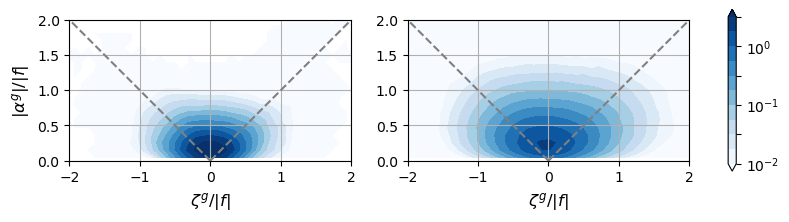

In [92]:
fig, axes = plt.subplots(figsize=(10,3), nrows=1, ncols=2)
# fig.set_tight_layout(True)

im = axes[0].contourf(hist_c.vort_bin,
                 hist_c.strain_bin,
                 hist_c, 
                 cmap='Blues', locator=ticker.LogLocator(), 
                 norm=clr.LogNorm(), levels=np.logspace(-2,.5,11),
                 extend='both'
#                       rasterized=True
               )
axes[1].contourf(hist_r.vort_bin,
                 hist_r.strain_bin,
                 hist_r, 
                 cmap='Blues', locator=ticker.LogLocator(), 
                 norm=clr.LogNorm(), levels=np.logspace(-2,.5,11),
                 extend='both'
#                       rasterized=True
               )

# for c in im.collections:
#     c.set_rasterized(True)

axes[0].plot(np.linspace(0,3,5),np.linspace(0,3,5),c='grey',ls='--')
axes[0].plot(np.linspace(-3,0,5),np.linspace(3,0,5),c='grey',ls='--')
axes[1].plot(np.linspace(0,3,5),np.linspace(0,3,5),c='grey',ls='--')
axes[1].plot(np.linspace(-3,0,5),np.linspace(3,0,5),c='grey',ls='--')

axes[0].set_xlim([-2,2])
axes[0].set_ylim([0,2])
axes[1].set_xlim([-2,2])
axes[1].set_ylim([0,2])

axes[0].set_xlabel(r"$\zeta^g/|f|$", fontsize=12)
axes[1].set_xlabel(r"$\zeta^g/|f|$", fontsize=12)
axes[0].set_ylabel(r"$|\alpha^g|/|f|$", fontsize=12)

axes[0].grid(True)
axes[0].set_aspect('equal')
axes[1].grid(True)
axes[1].set_aspect('equal')

# fig.subplots_adjust(hspace=.06, wspace=.12)
# cbar = fig.colorbar(im, orientation='horizontal', ax=axes, shrink=.4, 
#                     ticks=[1e-4,1e-3,1e-2,1e-1,1e0])
cbar = fig.colorbar(im, ax=axes, shrink=.7)
# cbar.set_ticks([1e-2,1e-1,0,1])

plt.savefig(op.join(ddir,"../Figs/vort-strain-KxjointPDF.pdf"))

# Gulf Stream

In [15]:
ds09 = xr.open_zarr(op.join(ddir,"SWOT_no_IT/CalVal_pass%03d_v2.0.1.zarr"
                            % 9))
ds09.coords["num_lines"] = ("num_lines",range(len(ds09.num_lines)))
ds09.coords["num_pixels"] = ("num_pixels",range(len(ds09.num_pixels)))

ds22 = xr.open_zarr(op.join(ddir,"SWOT_no_IT/CalVal_pass%03d_v2.0.1.zarr"
                            % 22))
ds22.coords["num_lines"] = ("num_lines",range(len(ds22.num_lines)))
ds22.coords["num_pixels"] = ("num_pixels",range(len(ds22.num_pixels)))
ds09,ds22

(<xarray.Dataset> Size: 582MB
 Dimensions:       (cycle_num: 105, num_lines: 9860, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 79kB 0 1 2 3 4 ... 9855 9856 9857 9858 9859
   * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 68
     latitude      (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9860, 69), meta=np.ndarray>
     longitude     (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9860, 69), meta=np.ndarray>
 Data variables:
     ssha_detided  (cycle_num, num_lines, num_pixels) float64 571MB dask.array<chunksize=(1, 9860, 69), meta=np.ndarray>,
 <xarray.Dataset> Size: 582MB
 Dimensions:       (cycle_num: 105, num_lines: 9860, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 79kB 0 1 2 3 4 ... 9855 9856 9857 9858 9859
   * num_pixels  

In [16]:
maskn9 = xr.DataArray(ds09.latitude.where(ds09.latitude<37.9).to_masked_array().mask,
                     dims=ds09.latitude.dims,
                     coords=ds09.latitude.coords
                    )
masks9 = xr.DataArray(ds09.latitude.where(ds09.latitude>32.5).to_masked_array().mask,
                     dims=ds09.latitude.dims,
                     coords=ds09.latitude.coords
                    )
xo09 = ds09.where(~maskn9,drop=True).where(~masks9,drop=True)

maskn2 = xr.DataArray(ds22.latitude.where(ds22.latitude<37.9).to_masked_array().mask,
                     dims=ds22.latitude.dims,
                     coords=ds22.latitude.coords
                    )
masks2 = xr.DataArray(ds22.latitude.where(ds22.latitude>32.5).to_masked_array().mask,
                     dims=ds22.latitude.dims,
                     coords=ds22.latitude.coords
                    )
xo22 = ds22.where(~maskn2,drop=True).where(~masks2,drop=True)
xo09, xo22

(<xarray.Dataset> Size: 19MB
 Dimensions:       (cycle_num: 105, num_lines: 321, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 3kB 6747 6748 6749 6750 ... 7065 7066 7067
   * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 68
     latitude      (num_lines, num_pixels) float64 177kB 32.5 32.5 ... 37.9 37.89
     longitude     (num_lines, num_pixels) float64 177kB 284.5 284.5 ... 287.4
 Data variables:
     ssha_detided  (cycle_num, num_lines, num_pixels) float64 19MB dask.array<chunksize=(1, 321, 69), meta=np.ndarray>,
 <xarray.Dataset> Size: 19MB
 Dimensions:       (cycle_num: 105, num_lines: 321, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 3kB 2794 2795 2796 2797 ... 3112 3113 3114
   * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 6

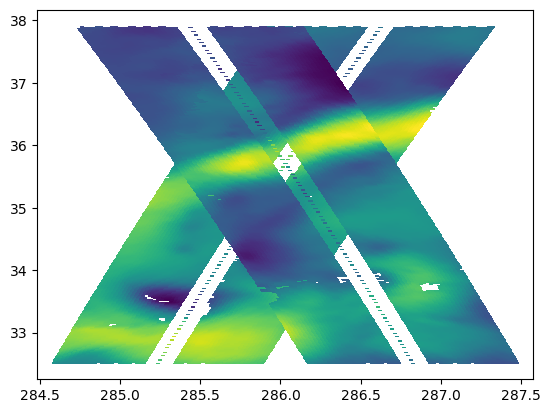

In [17]:
fig, ax = plt.subplots()
ax.pcolormesh(xo09.longitude, xo09.latitude,
              xo09.ssha_detided.isel(cycle_num=10),
              rasterized=True
             )
ax.pcolormesh(xo22.longitude, xo22.latitude,
              xo22.ssha_detided.isel(cycle_num=10),
              rasterized=True
             )

In [18]:
inp = 3

mask09 = xr.DataArray(xo09.ssha_detided.to_masked_array().mask.mean(axis=0), 
                     dims=xo09.ssha_detided.isel(cycle_num=0).dims, 
                     coords=xo09.ssha_detided.isel(cycle_num=0).coords
                    )
mm09 = xr.DataArray(mask09.where(mask09<.5
                              ).to_masked_array().mask,
                   dims=xo09.ssha_detided.isel(cycle_num=0).dims, 
                   coords=xo09.ssha_detided.isel(cycle_num=0).coords
                  ).isel(num_pixels=slice(inp,-inp))
mask22 = xr.DataArray(xo22.ssha_detided.to_masked_array().mask.mean(axis=0), 
                     dims=xo22.ssha_detided.isel(cycle_num=0).dims, 
                     coords=xo22.ssha_detided.isel(cycle_num=0).coords
                    )
mm22 = xr.DataArray(mask22.where(mask22<.5
                              ).to_masked_array().mask,
                   dims=xo22.ssha_detided.isel(cycle_num=0).dims, 
                   coords=xo22.ssha_detided.isel(cycle_num=0).coords
                  ).isel(num_pixels=slice(inp,-inp))
mm09, mm22

(<xarray.DataArray (num_lines: 321, num_pixels: 63)> Size: 20kB
 array([[ True,  True,  True, ...,  True,  True,  True],
        [ True, False, False, ...,  True,  True,  True],
        [ True, False, False, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ..., False, False,  True],
        [ True,  True,  True, ..., False, False,  True],
        [ True,  True,  True, ...,  True,  True,  True]], shape=(321, 63))
 Coordinates:
   * num_lines   (num_lines) int64 3kB 6747 6748 6749 6750 ... 7065 7066 7067
   * num_pixels  (num_pixels) int64 504B 3 4 5 6 7 8 9 ... 59 60 61 62 63 64 65
     cycle_num   int64 8B 474
     latitude    (num_lines, num_pixels) float64 162kB 32.49 32.49 ... 37.91
     longitude   (num_lines, num_pixels) float64 162kB 284.6 284.6 ... 287.4,
 <xarray.DataArray (num_lines: 321, num_pixels: 63)> Size: 20kB
 array([[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ..., False,  True,  True],
        [ True,  True,  True

In [22]:
low09 = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass%03d/SSHa.zarr" 
                               % 9)
                      ).ssha.where(~maskn9,drop=True).where(~masks9,drop=True)
low22 = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass%03d/SSHa.zarr" 
                               % 22)
                      ).ssha.where(~maskn2,drop=True).where(~masks2,drop=True)
low09, low22

(<xarray.DataArray 'ssha' (cycle_num: 105, num_lines: 319, num_pixels: 61)> Size: 16MB
 dask.array<where, shape=(105, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 3kB 6748 6749 6750 6751 ... 7064 7065 7066
   * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
     latitude    (num_lines, num_pixels) float64 156kB 32.51 32.51 ... 37.9 37.89
     longitude   (num_lines, num_pixels) float64 156kB 284.6 284.6 ... 287.3,
 <xarray.DataArray 'ssha' (cycle_num: 105, num_lines: 319, num_pixels: 61)> Size: 16MB
 dask.array<where, shape=(105, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 3kB 2795 2796 2797 2798 ... 3111 3112 3113
   * num_pixels  (num_pixels) i

In [23]:
r_ref9 = (~mm09).sum() / np.prod(mm09.shape)
r_ref2 = (~mm22).sum() / np.prod(mm22.shape)
r_ref2

<xarray.DataArray ()> Size: 8B
array(0.80660634)
Coordinates:
    cycle_num  int64 8B 474

In [24]:
ageo = (1e-2*ds09.ssha_detided
        - low09
       )
ic = 0
for cc in ageo.cycle_num:

    sshg = low09.sel(cycle_num=cc)
    ssha = ageo.sel(cycle_num=cc)
    
    array = ssha.to_masked_array()
    mask = ~array.mask
    ratio = mask.sum() / np.prod(mask.shape)
    if ic == 0:
        r09 = xr.DataArray(np.array([ratio]), 
                           dims='cycle_num', 
                           coords={'cycle_num':np.array([cc.values,])}
                          )
    else:
        r09 = xr.concat([r09, xr.DataArray(np.array([ratio]), 
                               dims='cycle_num', 
                               coords={'cycle_num':np.array([cc.values,])}
                                          )
                        ], 'cycle_num')
    if ratio > .7*r_ref9:
        if ic == 0:
            a09 = ssha
        else:
            try:
                a09 = xr.concat([a09, ssha], 'cycle_num')
            except:
                pass
        ic += 1
    # else:
    #     ssha.plot(rasterized=True)
    #     plt.show()
    del ssha, mask, array

a09.coords["cycle_num"] = ("cycle_num",
                           r09.where(r09>0.7*r_ref9, drop=True).cycle_num.data
                          )

dsa09 = a09.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsa09.coords["y"] = ("y",range(len(dsa09.y)))
dsa09.coords["x"] = ("x",range(len(dsa09.x)))
if not dsa09.rio.crs:
    dsa09 = dsa09.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsa09.ssha.rio.nodata is None:
    dsa09["ssha"] = dsa09.ssha.rio.write_nodata(np.nan)
_a09_exterp = dsa09.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_a09_interp = _a09_exterp.interp(cycle_num=ds09.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
a09_exterp = _a09_exterp.where(mm09.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds09.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsa09.close()

dsg09 = low09.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsg09.coords["y"] = ("y",range(len(dsg09.y)))
dsg09.coords["x"] = ("x",range(len(dsg09.x)))
if not dsg09.rio.crs:
    dsg09 = dsg09.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsg09.ssha.rio.nodata is None:
    dsg09["ssha"] = dsg09.ssha.rio.write_nodata(np.nan)
_g09_exterp = dsg09.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_g09_interp = _g09_exterp.interp(cycle_num=ds09.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
g09_exterp = _g09_exterp.where(mm09.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds09.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsg09.close()

In [25]:
ageo = (1e-2*ds22.ssha_detided
        - low22
       )
ic = 0
for cc in ageo.cycle_num:

    sshg = low22.sel(cycle_num=cc)
    ssha = ageo.sel(cycle_num=cc)
    
    array = ssha.to_masked_array()
    mask = ~array.mask
    ratio = mask.sum() / np.prod(mask.shape)
    if ic == 0:
        r22 = xr.DataArray(np.array([ratio]), 
                           dims='cycle_num', 
                           coords={'cycle_num':np.array([cc.values,])}
                          )
    else:
        r22 = xr.concat([r22, xr.DataArray(np.array([ratio]), 
                               dims='cycle_num', 
                               coords={'cycle_num':np.array([cc.values,])}
                                          )
                        ], 'cycle_num')
    if ratio > .7*r_ref2:
        if ic == 0:
            a22 = ssha
        else:
            try:
                a22 = xr.concat([a22, ssha], 'cycle_num')
            except:
                pass
        ic += 1
    # else:
    #     ssha.plot(rasterized=True)
    #     plt.show()
    del ssha, mask, array

a22.coords["cycle_num"] = ("cycle_num",
                           r22.where(r22>0.7*r_ref2, drop=True).cycle_num.data
                          )

dsa22 = a22.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsa22.coords["y"] = ("y",range(len(dsa22.y)))
dsa22.coords["x"] = ("x",range(len(dsa22.x)))
if not dsa22.rio.crs:
    dsa22 = dsa22.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsa22.ssha.rio.nodata is None:
    dsa22["ssha"] = dsa22.ssha.rio.write_nodata(np.nan)
_a22_exterp = dsa22.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_a22_interp = _a22_exterp.interp(cycle_num=ds22.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
a22_exterp = _a22_exterp.where(mm22.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds22.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsa22.close()

dsg22 = low22.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsg22.coords["y"] = ("y",range(len(dsg22.y)))
dsg22.coords["x"] = ("x",range(len(dsg22.x)))
if not dsg22.rio.crs:
    dsg22 = dsg22.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsg22.ssha.rio.nodata is None:
    dsg22["ssha"] = dsg22.ssha.rio.write_nodata(np.nan)
_g22_exterp = dsg22.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_g22_interp = _g22_exterp.interp(cycle_num=ds22.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
g22_exterp = _g22_exterp.where(mm22.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds22.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsg22.close()

In [26]:
for cc in low09.cycle_num:
    if cc == low09.cycle_num[0]:
        ar_g9 = g09_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        ar_a9 = a09_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])

        ar_g2 = g22_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        ar_a2 = a22_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
    else:
        ar_g9 = xr.concat([ar_g9, 
                          g09_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_a9 = xr.concat([ar_a9, 
                          a09_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_g2 = xr.concat([ar_g2, 
                          g22_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_a2 = xr.concat([ar_a2, 
                          a22_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")

ar_g9.coords["time"] = ("time",np.arange(len(ar_g9.time))*24*60.*60)
ar_a9.coords["time"] = ("time",np.arange(len(ar_a9.time))*24*60.*60)
ar_g2.coords["time"] = ("time",np.arange(len(ar_g2.time))*24*60.*60)
ar_a2.coords["time"] = ("time",np.arange(len(ar_a2.time))*24*60.*60)
ar_g9.coords["num_lines"] = ("num_lines",np.arange(len(ar_g9.num_lines))*2e3)
ar_a9.coords["num_lines"] = ("num_lines",np.arange(len(ar_a9.num_lines))*2e3)
ar_g2.coords["num_lines"] = ("num_lines",np.arange(len(ar_g2.num_lines))*2e3)
ar_a2.coords["num_lines"] = ("num_lines",np.arange(len(ar_a2.num_lines))*2e3)

ar_g9, ar_a2

(<xarray.DataArray 'ssha' (time: 105, num_lines: 294, num_pixels: 2)> Size: 494kB
 array([[[-0.01159815,  0.22678214],
         [-0.01328404,  0.22183781],
         [-0.01426868,  0.21685487],
         ...,
         [ 0.05864427,  0.05514356],
         [ 0.05970473,  0.05512229],
         [ 0.06058492,  0.05496467]],
 
        [[-0.01187026,  0.21478142],
         [-0.01413821,  0.21087999],
         [-0.01587318,  0.2069253 ],
         ...,
         [ 0.0542359 ,  0.02979481],
         [ 0.05551091,  0.02981698],
         [ 0.056437  ,  0.02967546]],
 
        [[ 0.00687169,  0.212486  ],
         [ 0.00453572,  0.20956886],
         [ 0.00253806,  0.20654591],
         ...,
 ...
         ...,
         [ 0.10068784,  0.24503463],
         [ 0.10083745,  0.23500745],
         [ 0.10083365,  0.22527078]],
 
        [[ 0.1267555 ,  0.13781288],
         [ 0.12988053,  0.12687892],
         [ 0.1332867 ,  0.11613282],
         ...,
         [ 0.10541569,  0.22044041],
         [ 0.1055753

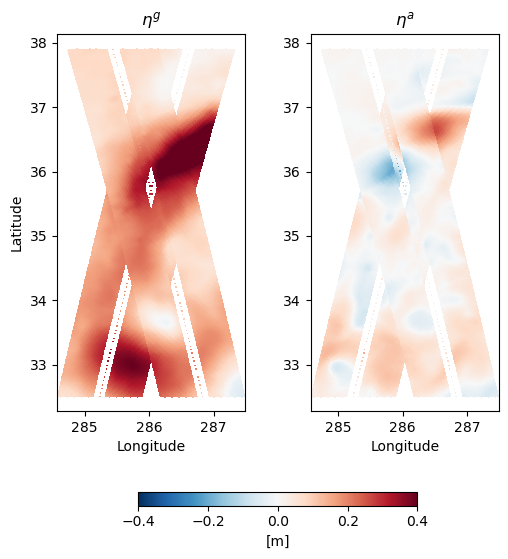

In [27]:
cnum = 20
fig, axes = plt.subplots(figsize=(6,7), nrows=1, ncols=2)
# fig.set_tight_layout(True)
im = axes[0].pcolormesh(g09_exterp.isel(cycle_num=cnum).longitude, 
                        g09_exterp.isel(cycle_num=cnum).latitude,
               g09_exterp.isel(cycle_num=cnum),
               vmin=-.4, vmax=.4, cmap="RdBu_r",
               rasterized=True)
axes[0].pcolormesh(g22_exterp.isel(cycle_num=cnum).longitude, 
                   g22_exterp.isel(cycle_num=cnum).latitude,
               g22_exterp.isel(cycle_num=cnum),
               vmin=-.4, vmax=.4, cmap="RdBu_r",
               rasterized=True)
axes[1].pcolormesh(a09_exterp.isel(cycle_num=cnum).longitude, 
                   a09_exterp.isel(cycle_num=cnum).latitude,
               a09_exterp.isel(cycle_num=cnum),
               vmin=-.4, vmax=.4, cmap="RdBu_r",
               rasterized=True)
axes[1].pcolormesh(a22_exterp.isel(cycle_num=cnum).longitude, 
                   a22_exterp.isel(cycle_num=cnum).latitude,
               a22_exterp.isel(cycle_num=cnum),
               vmin=-.4, vmax=.4, cmap="RdBu_r",
               rasterized=True)
axes[0].set_aspect("equal")
axes[1].set_aspect("equal")
axes[0].set_xlabel(r"Longitude")
axes[0].set_ylabel(r"Latitude")
axes[1].set_xlabel(r"Longitude")
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.6)
cbar.set_label(r"[m]")
axes[0].set_title(r"$\eta^g$")
axes[1].set_title(r"$\eta^a$")
plt.savefig(op.join(ddir,"../Figs/ssha-GS.pdf"))

In [28]:
Fg2 = xrft.power_spectrum(ar_g2.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fg2 = xrft.power_spectrum(Fg2.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa2 = xrft.power_spectrum(ar_a2.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fa2 = xrft.power_spectrum(Fa2.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fg9 = xrft.power_spectrum(ar_g9.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fg9 = xrft.power_spectrum(Fg9.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa9 = xrft.power_spectrum(ar_a9.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fa9 = xrft.power_spectrum(Fa9.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa = .5*(Fa2 + Fa9)
Fg = .5*(Fg2 + Fg9)
Fg, Fa

(<xarray.DataArray (freq_time: 105, freq_num_lines: 294)> Size: 247kB
 dask.array<mul, shape=(105, 294), dtype=float64, chunksize=(105, 294), chunktype=numpy.ndarray>
 Coordinates:
   * freq_time       (freq_time) float64 840B -5.732e-06 -5.622e-06 ... 5.732e-06
   * freq_num_lines  (freq_num_lines) float64 2kB -0.00025 ... 0.0002483,
 <xarray.DataArray (freq_time: 105, freq_num_lines: 294)> Size: 247kB
 dask.array<mul, shape=(105, 294), dtype=float64, chunksize=(105, 294), chunktype=numpy.ndarray>
 Coordinates:
   * freq_time       (freq_time) float64 840B -5.732e-06 -5.622e-06 ... 5.732e-06
   * freq_num_lines  (freq_num_lines) float64 2kB -0.00025 ... 0.0002483)

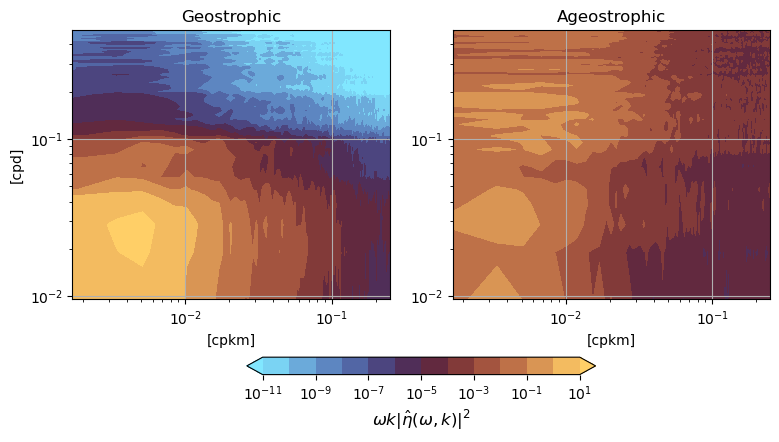

In [29]:
fig, axes = plt.subplots(figsize=(9,5), nrows=1, ncols=2)
# fig.set_tight_layout(True)
im = axes[0].contourf(Fg.freq_num_lines.isel(freq_num_lines=slice(len(Fg.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fg.freq_time.isel(freq_time=slice(len(Fg.freq_time)//2,
                                                 None)).values*86400,
               (Fg.freq_num_lines*Fg.freq_time*Fg
               ).isel(freq_num_lines=slice(len(Fg.freq_num_lines)//2,None),
                      freq_time=slice(len(Fg.freq_time)//2,None)
                     ).values.T*4,
               levels=np.logspace(-11,1,13),
               norm=clr.LogNorm(), cmap="managua_r",
               extend="both",
               rasterized=True
              )
axes[1].contourf(Fa.freq_num_lines.isel(freq_num_lines=slice(len(Fa.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fa.freq_time.isel(freq_time=slice(len(Fa.freq_time)//2,
                                                 None)).values*86400,
               (Fa.freq_num_lines*Fa.freq_time*Fa
               ).isel(freq_num_lines=slice(len(Fa.freq_num_lines)//2,None),
                      freq_time=slice(len(Fa.freq_time)//2,None)
                     ).values.T*4,
               levels=np.logspace(-11,1,13),
               norm=clr.LogNorm(), cmap="managua_r",
                 extend="both",
               rasterized=True
              )
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlim([Fg.freq_num_lines.where(Fg.freq_num_lines>0.).min()*1e3,
              Fg.freq_num_lines.where(Fg.freq_num_lines>0.).max()*1e3])
axes[0].set_ylim([Fg.freq_time.where(Fg.freq_time>0.).min()*86400,
              Fg.freq_time.where(Fg.freq_time>0.).max()*86400])
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlim([Fa.freq_num_lines.where(Fa.freq_num_lines>0.).min()*1e3,
              Fa.freq_num_lines.where(Fa.freq_num_lines>0.).max()*1e3])
axes[1].set_ylim([Fa.freq_time.where(Fa.freq_time>0.).min()*86400,
              Fa.freq_time.where(Fa.freq_time>0.).max()*86400])
axes[0].set_xlabel(r"[cpkm]")
axes[1].set_xlabel(r"[cpkm]")
axes[0].set_ylabel(r"[cpd]")
axes[0].grid(True)
axes[1].grid(True)
axes[0].set_title(r"Geostrophic")
axes[1].set_title(r"Ageostrophic")
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.5)
cbar.set_label(r"$\omega k |\hat{\eta}(\omega,k)|^2$", fontsize=12)
plt.savefig(op.join(ddir,"../Figs/omega-k_GS.pdf"))

In [28]:
dsv2 = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass022/SSVs_SwotDiag.zarr"))
dsv9 = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass009/SSVs_SwotDiag.zarr"))
dsv2r = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass022/SSVs_rawSwotDiag.zarr"))
dsv9r = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass009/SSVs_rawSwotDiag.zarr"))
dsv2, dsv9

(<xarray.Dataset> Size: 3GB
 Dimensions:     (cycle_num: 105, num_lines: 9310, num_pixels: 61)
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 74kB 1 2 3 4 5 6 ... 9854 9855 9856 9857 9858
   * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
     latitude    (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9310, 61), meta=np.ndarray>
     longitude   (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9310, 61), meta=np.ndarray>
 Data variables:
     strain      (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>
     ucg         (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>
     ug          (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>
     vcg         (cycle_num, num_lines, num_pixels) float64 477MB das

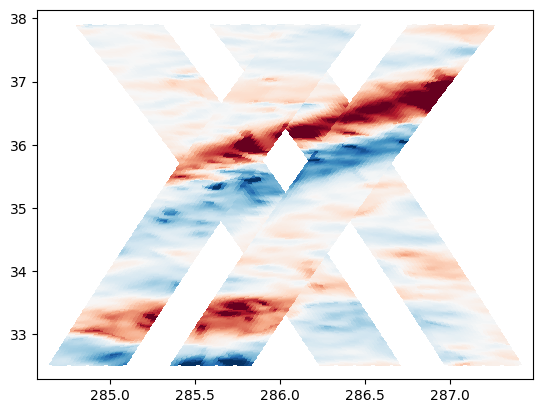

In [29]:
u2 = dsv2.ucg.where(~maskn2,drop=True).where(~masks2,drop=True)
u9 = dsv9.ucg.where(~maskn9,drop=True).where(~masks9,drop=True)

fig, ax = plt.subplots()
ax.pcolormesh(u2.longitude, u2.latitude,
              u2.isel(cycle_num=11),
              vmax=.8, vmin=-.8, cmap="RdBu_r",
              rasterized=True
             )
ax.pcolormesh(u9.longitude, u9.latitude,
              u9.isel(cycle_num=11),
              vmax=.8, vmin=-.8, cmap="RdBu_r",
              rasterized=True
             )

In [30]:
sp2 = np.sqrt(dsv2.ucg**2 + dsv2.vcg**2).where(~maskn2,drop=True).where(~masks2,drop=True)
sp9 = np.sqrt(dsv9.ucg**2 + dsv9.vcg**2).where(~maskn9,drop=True).where(~masks9,drop=True)
v2 = dsv2.vort.where(~maskn2,drop=True).where(~masks2,drop=True)
s2 = dsv2.strain.where(~maskn2,drop=True).where(~masks2,drop=True)
v9 = dsv9.vort.where(~maskn9,drop=True).where(~masks9,drop=True)
s9 = dsv9.strain.where(~maskn9,drop=True).where(~masks9,drop=True)
v2r = dsv2r.vort.where(~maskn2,drop=True
                      ).where(~masks2,drop=True
                             ).isel(num_pixels=slice(4,-4),
                                    num_lines=slice(1,-1)
                                   ).dropna("cycle_num", how="all")
s2r = dsv2r.strain.where(~maskn2,drop=True
                        ).where(~masks2,drop=True
                               ).isel(num_pixels=slice(4,-4),
                                      num_lines=slice(1,-1)
                                     ).dropna("cycle_num", how="all")
v9r = dsv9r.vort.where(~maskn9,drop=True
                      ).where(~masks9,drop=True
                             ).isel(num_pixels=slice(4,-4),
                                    num_lines=slice(1,-1)
                                   ).dropna("cycle_num", how="all")
s9r = dsv9r.strain.where(~maskn9,drop=True
                        ).where(~masks9,drop=True
                               ).isel(num_pixels=slice(4,-4),
                                      num_lines=slice(1,-1)
                                     ).dropna("cycle_num", how="all")
v2, v2r

(<xarray.DataArray 'vort' (cycle_num: 105, num_lines: 319, num_pixels: 61)> Size: 16MB
 dask.array<where, shape=(105, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 3kB 2795 2796 2797 2798 ... 3111 3112 3113
   * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
     latitude    (num_lines, num_pixels) float64 156kB 38.13 38.12 ... 32.3 32.3
     longitude   (num_lines, num_pixels) float64 156kB 286.1 286.0 ... 286.2,
 <xarray.DataArray 'vort' (cycle_num: 97, num_lines: 319, num_pixels: 61)> Size: 15MB
 dask.array<getitem, shape=(97, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 776B 474 476 478 479 480 ... 574 575 576 577
   * num_lines   (num_lines) int64 3kB 2795 2796 2797 2798 ... 3111 3112 3113
   * num_pixels  (num_pixels) in

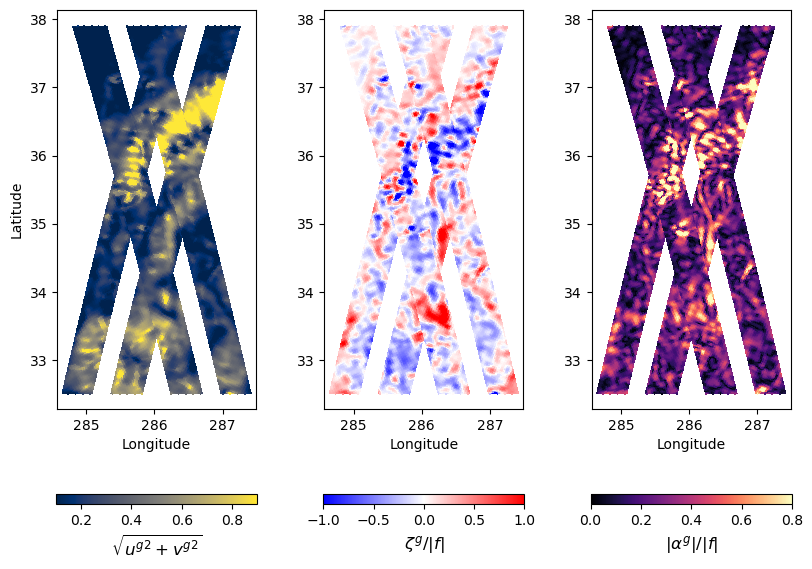

In [33]:
fig, (ax0, ax1,ax2) = plt.subplots(figsize=(9,6), nrows=1, ncols=3)
fig.set_tight_layout(True)
ax0.pcolormesh(sp9.isel(cycle_num=cnum).longitude, sp9.isel(cycle_num=cnum).latitude,
               sp9.isel(cycle_num=cnum),
               vmin=.1, vmax=.9, cmap="cividis",
               rasterized=True)
im0 = ax0.pcolormesh(sp2.isel(cycle_num=cnum).longitude, sp2.isel(cycle_num=cnum).latitude,
               sp2.isel(cycle_num=cnum),
               vmin=.1, vmax=.9, cmap="cividis",
               rasterized=True)
ax1.pcolormesh(v9.isel(cycle_num=cnum).longitude, v9.isel(cycle_num=cnum).latitude,
               (v9.isel(cycle_num=cnum) 
                / np.abs(gsw.f(v9.isel(cycle_num=cnum).latitude))),
               vmin=-1, vmax=1, cmap="bwr",
               rasterized=True)
im1 = ax1.pcolormesh(v2.isel(cycle_num=cnum).longitude, v2.isel(cycle_num=cnum).latitude,
               (v2.isel(cycle_num=cnum) 
                / np.abs(gsw.f(v2.isel(cycle_num=cnum).latitude))),
               vmin=-1, vmax=1, cmap="bwr",
               rasterized=True)
ax2.pcolormesh(s9.isel(cycle_num=cnum).longitude, s9.isel(cycle_num=cnum).latitude,
               (s9.isel(cycle_num=cnum) 
                / np.abs(gsw.f(s9.isel(cycle_num=cnum).latitude))),
               vmax=.8, vmin=0., cmap="magma",
               rasterized=True)
im2 = ax2.pcolormesh(s2.isel(cycle_num=cnum).longitude, s2.isel(cycle_num=cnum).latitude,
               (s2.isel(cycle_num=cnum) 
                / np.abs(gsw.f(s2.isel(cycle_num=cnum).latitude))),
               vmax=.8, vmin=0., cmap="magma",
               rasterized=True)
ax0.set_aspect("equal")
ax1.set_aspect("equal")
ax2.set_aspect("equal")
ax0.set_xlabel(r"Longitude")
ax1.set_xlabel(r"Longitude")
ax0.set_ylabel(r"Latitude")
ax2.set_xlabel(r"Longitude")
cbar0 = fig.colorbar(im0, ax=ax0, orientation="horizontal", shrink=.6)
cbar1 = fig.colorbar(im1, ax=ax1, orientation="horizontal", shrink=.6)
cbar2 = fig.colorbar(im2, ax=ax2, orientation="horizontal", shrink=.6)
cbar0.set_label(r"$\sqrt{{u^g}^2 + {v^g}^2}$", fontsize=12)
cbar1.set_label(r"$\zeta^g/|f|$", fontsize=12)
cbar2.set_label(r"$|\alpha^g|/|f|$", fontsize=12)
plt.savefig(op.join(ddir,"../Figs/vort-strain-GS.pdf"))

In [36]:
vort = xr.concat([v2.drop_vars(["cycle_num","num_lines","num_pixels"]),
                  v9.drop_vars(["cycle_num","num_lines","num_pixels"])
                 ], "cycle_num")
strain = xr.concat([s2.drop_vars(["cycle_num","num_lines","num_pixels"]),
                  s9.drop_vars(["cycle_num","num_lines","num_pixels"])
                 ], "cycle_num")
f = gsw.f(vort.latitude)
vort_raw = xr.concat([v2r.drop_vars(["cycle_num","num_lines","num_pixels"]),
                  v9r.drop_vars(["cycle_num","num_lines","num_pixels"])
                 ], "cycle_num")
str_raw = xr.concat([s2r.drop_vars(["cycle_num","num_lines","num_pixels"]),
                  s9r.drop_vars(["cycle_num","num_lines","num_pixels"])
                 ], "cycle_num")
fr = gsw.f(vort_raw.latitude)
vort, strain, f

(<xarray.DataArray 'vort' (cycle_num: 210, num_lines: 319, num_pixels: 61)> Size: 33MB
 dask.array<concatenate, shape=(210, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
     latitude   (cycle_num, num_lines, num_pixels) float64 33MB 38.13 ... 37.89
     longitude  (cycle_num, num_lines, num_pixels) float64 33MB 286.1 ... 287.3
 Dimensions without coordinates: cycle_num, num_lines, num_pixels,
 <xarray.DataArray 'strain' (cycle_num: 210, num_lines: 319, num_pixels: 61)> Size: 33MB
 dask.array<concatenate, shape=(210, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
     latitude   (cycle_num, num_lines, num_pixels) float64 33MB 38.13 ... 37.89
     longitude  (cycle_num, num_lines, num_pixels) float64 33MB 286.1 ... 287.3
 Dimensions without coordinates: cycle_num, num_lines, num_pixels,
 <xarray.DataArray 'latitude' (cycle_num: 210, num_lines: 319, num_pixels: 61)> Size: 33MB
 array([[[9.00471062e-05, 9.0

In [37]:
vbins = np.linspace(-3e0,3e0,60)
sbins = np.linspace(0,3e0,30)
hist_c = xhist((strain / np.abs(f)).rename('strain'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               (vort / np.abs(f)).rename('vort'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               bins=[sbins, vbins], density=True
              ).compute()
hist_r = xhist((str_raw / np.abs(fr)).rename('strain'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               (vort_raw / np.abs(fr)).rename('vort'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               bins=[sbins, vbins], density=True
              ).compute()

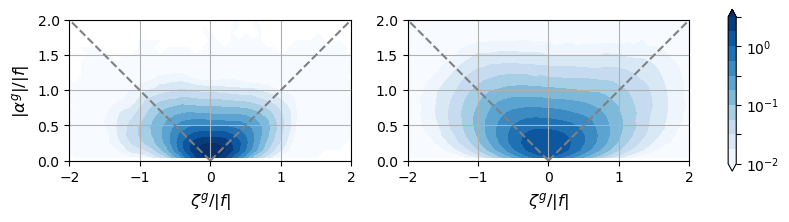

In [38]:
fig, axes = plt.subplots(figsize=(10,3), nrows=1, ncols=2)
# fig.set_tight_layout(True)

im = axes[0].contourf(hist_c.vort_bin,
                 hist_c.strain_bin,
                 hist_c, 
                 cmap='Blues', locator=ticker.LogLocator(), 
                 norm=clr.LogNorm(), levels=np.logspace(-2,.5,11),
                 extend='both'
#                       rasterized=True
               )
axes[1].contourf(hist_r.vort_bin,
                 hist_r.strain_bin,
                 hist_r, 
                 cmap='Blues', locator=ticker.LogLocator(), 
                 norm=clr.LogNorm(), levels=np.logspace(-2,.5,11),
                 extend='both'
#                       rasterized=True
               )

# for c in im.collections:
#     c.set_rasterized(True)

axes[0].plot(np.linspace(0,3,5),np.linspace(0,3,5),c='grey',ls='--')
axes[0].plot(np.linspace(-3,0,5),np.linspace(3,0,5),c='grey',ls='--')
axes[1].plot(np.linspace(0,3,5),np.linspace(0,3,5),c='grey',ls='--')
axes[1].plot(np.linspace(-3,0,5),np.linspace(3,0,5),c='grey',ls='--')

axes[0].set_xlim([-2,2])
axes[0].set_ylim([0,2])
axes[1].set_xlim([-2,2])
axes[1].set_ylim([0,2])

axes[0].set_xlabel(r"$\zeta^g/|f|$", fontsize=12)
axes[1].set_xlabel(r"$\zeta^g/|f|$", fontsize=12)
axes[0].set_ylabel(r"$|\alpha^g|/|f|$", fontsize=12)

axes[0].grid(True)
axes[0].set_aspect('equal')
axes[1].grid(True)
axes[1].set_aspect('equal')

# fig.subplots_adjust(hspace=.06, wspace=.12)
# cbar = fig.colorbar(im, orientation='horizontal', ax=axes, shrink=.4, 
#                     ticks=[1e-4,1e-3,1e-2,1e-1,1e0])
cbar = fig.colorbar(im, ax=axes, shrink=.7)
# cbar.set_ticks([1e-2,1e-1,0,1])

plt.savefig(op.join(ddir,"../Figs/vort-strain-GSjointPDF.pdf"))

# California

In [4]:
ds13 = xr.open_zarr(op.join(ddir,"SWOT_no_IT/CalVal_pass%03d_v2.0.1.zarr"
                            % 13))
ds13.coords["num_lines"] = ("num_lines",range(len(ds13.num_lines)))
ds13.coords["num_pixels"] = ("num_pixels",range(len(ds13.num_pixels)))

ds26 = xr.open_zarr(op.join(ddir,"SWOT_no_IT/CalVal_pass%03d_v2.0.1.zarr"
                            % 26))
ds26.coords["num_lines"] = ("num_lines",range(len(ds26.num_lines)))
ds26.coords["num_pixels"] = ("num_pixels",range(len(ds26.num_pixels)))
ds13,ds26

(<xarray.Dataset> Size: 582MB
 Dimensions:       (cycle_num: 105, num_lines: 9860, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 79kB 0 1 2 3 4 ... 9855 9856 9857 9858 9859
   * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 68
     latitude      (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9860, 69), meta=np.ndarray>
     longitude     (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9860, 69), meta=np.ndarray>
 Data variables:
     ssha_detided  (cycle_num, num_lines, num_pixels) float64 571MB dask.array<chunksize=(1, 9860, 69), meta=np.ndarray>,
 <xarray.Dataset> Size: 582MB
 Dimensions:       (cycle_num: 105, num_lines: 9860, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 79kB 0 1 2 3 4 ... 9855 9856 9857 9858 9859
   * num_pixels  

In [5]:
maskn3 = xr.DataArray(ds13.latitude.where(ds13.latitude<38.4).to_masked_array().mask,
                     dims=ds13.latitude.dims,
                     coords=ds13.latitude.coords
                    )
masks3 = xr.DataArray(ds13.latitude.where(ds13.latitude>33.).to_masked_array().mask,
                     dims=ds13.latitude.dims,
                     coords=ds13.latitude.coords
                    )
xo13 = ds13.where(~maskn3,drop=True).where(~masks3,drop=True)

maskn6 = xr.DataArray(ds26.latitude.where(ds26.latitude<38.4).to_masked_array().mask,
                     dims=ds26.latitude.dims,
                     coords=ds26.latitude.coords
                    )
masks6 = xr.DataArray(ds26.latitude.where(ds26.latitude>33.).to_masked_array().mask,
                     dims=ds26.latitude.dims,
                     coords=ds26.latitude.coords
                    )
xo26 = ds26.where(~maskn6,drop=True).where(~masks6,drop=True)
xo13, xo26

(<xarray.Dataset> Size: 19MB
 Dimensions:       (cycle_num: 105, num_lines: 321, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 3kB 6775 6776 6777 6778 ... 7093 7094 7095
   * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 68
     latitude      (num_lines, num_pixels) float64 177kB 33.0 33.0 ... 38.38
     longitude     (num_lines, num_pixels) float64 177kB 233.2 233.2 ... 236.1
 Data variables:
     ssha_detided  (cycle_num, num_lines, num_pixels) float64 19MB dask.array<chunksize=(1, 321, 69), meta=np.ndarray>,
 <xarray.Dataset> Size: 19MB
 Dimensions:       (cycle_num: 105, num_lines: 321, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 3kB 2766 2767 2768 2769 ... 3084 3085 3086
   * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 

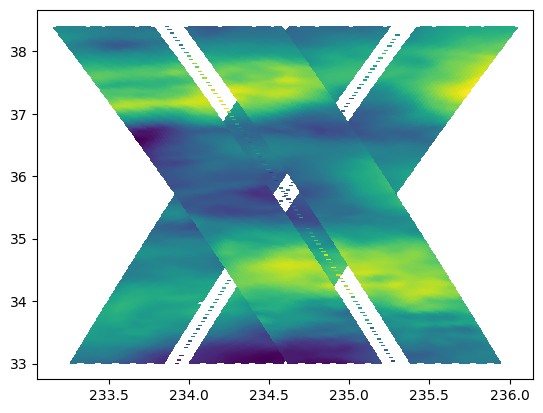

In [8]:
fig, ax = plt.subplots()
ax.pcolormesh(xo13.longitude, xo13.latitude,
              xo13.ssha_detided.isel(cycle_num=10),
              rasterized=True
             )
ax.pcolormesh(xo26.longitude, xo26.latitude,
              xo26.ssha_detided.isel(cycle_num=10),
              rasterized=True
             )

In [6]:
inp = 3

mask13 = xr.DataArray(xo13.ssha_detided.to_masked_array().mask.mean(axis=0), 
                     dims=xo13.ssha_detided.isel(cycle_num=0).dims, 
                     coords=xo13.ssha_detided.isel(cycle_num=0).coords
                    )
mm13 = xr.DataArray(mask13.where(mask13<.5
                              ).to_masked_array().mask,
                   dims=xo13.ssha_detided.isel(cycle_num=0).dims, 
                   coords=xo13.ssha_detided.isel(cycle_num=0).coords
                  ).isel(num_pixels=slice(inp,-inp))
mask26 = xr.DataArray(xo26.ssha_detided.to_masked_array().mask.mean(axis=0), 
                     dims=xo26.ssha_detided.isel(cycle_num=0).dims, 
                     coords=xo26.ssha_detided.isel(cycle_num=0).coords
                    )
mm26 = xr.DataArray(mask26.where(mask26<.5
                              ).to_masked_array().mask,
                   dims=xo26.ssha_detided.isel(cycle_num=0).dims, 
                   coords=xo26.ssha_detided.isel(cycle_num=0).coords
                  ).isel(num_pixels=slice(inp,-inp))
mm13, mm26

(<xarray.DataArray (num_lines: 321, num_pixels: 63)> Size: 20kB
 array([[ True,  True,  True, ...,  True,  True,  True],
        [ True, False, False, ...,  True,  True,  True],
        [ True, False, False, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ..., False, False,  True],
        [ True,  True,  True, ..., False, False,  True],
        [ True,  True,  True, ...,  True,  True,  True]], shape=(321, 63))
 Coordinates:
   * num_lines   (num_lines) int64 3kB 6775 6776 6777 6778 ... 7093 7094 7095
   * num_pixels  (num_pixels) int64 504B 3 4 5 6 7 8 9 ... 59 60 61 62 63 64 65
     cycle_num   int64 8B 474
     latitude    (num_lines, num_pixels) float64 162kB 32.99 32.99 ... 38.4 38.4
     longitude   (num_lines, num_pixels) float64 162kB 233.2 233.3 ... 236.1,
 <xarray.DataArray (num_lines: 321, num_pixels: 63)> Size: 20kB
 array([[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ..., False, False,  True],
        [ True,  True,  

In [7]:
low13 = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass%03d/SSHa.zarr" 
                               % 13)
                      ).ssha.where(~maskn3,drop=True).where(~masks3,drop=True)
low26 = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass%03d/SSHa.zarr" 
                               % 26)
                      ).ssha.where(~maskn6,drop=True).where(~masks6,drop=True)
low13, low26

(<xarray.DataArray 'ssha' (cycle_num: 105, num_lines: 319, num_pixels: 61)> Size: 16MB
 dask.array<where, shape=(105, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 3kB 6776 6777 6778 6779 ... 7092 7093 7094
   * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
     latitude    (num_lines, num_pixels) float64 156kB 33.0 33.0 ... 38.39 38.38
     longitude   (num_lines, num_pixels) float64 156kB 233.3 233.3 ... 236.0,
 <xarray.DataArray 'ssha' (cycle_num: 105, num_lines: 319, num_pixels: 61)> Size: 16MB
 dask.array<where, shape=(105, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 3kB 2767 2768 2769 2770 ... 3083 3084 3085
   * num_pixels  (num_pixels) in

In [8]:
r_ref3 = (~mm13).sum() / np.prod(mm13.shape)
r_ref6 = (~mm26).sum() / np.prod(mm26.shape)
r_ref6

<xarray.DataArray ()> Size: 8B
array(0.82247936)
Coordinates:
    cycle_num  int64 8B 474

In [9]:
ageo = (1e-2*ds13.ssha_detided
        - low13
       )
ic = 0
for cc in ageo.cycle_num:

    sshg = low13.sel(cycle_num=cc)
    ssha = ageo.sel(cycle_num=cc)
    
    array = ssha.to_masked_array()
    mask = ~array.mask
    ratio = mask.sum() / np.prod(mask.shape)
    if ic == 0:
        r13 = xr.DataArray(np.array([ratio]), 
                           dims='cycle_num', 
                           coords={'cycle_num':np.array([cc.values,])}
                          )
    else:
        r13 = xr.concat([r13, xr.DataArray(np.array([ratio]), 
                               dims='cycle_num', 
                               coords={'cycle_num':np.array([cc.values,])}
                                          )
                        ], 'cycle_num')
    if ratio > .7*r_ref3:
        if ic == 0:
            a13 = ssha
        else:
            try:
                a13 = xr.concat([a13, ssha], 'cycle_num')
            except:
                pass
        ic += 1
    # else:
    #     ssha.plot(rasterized=True)
    #     plt.show()
    del ssha, mask, array

a13.coords["cycle_num"] = ("cycle_num",
                           r13.where(r13>0.7*r_ref3, drop=True).cycle_num.data
                          )

dsa13 = a13.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsa13.coords["y"] = ("y",range(len(dsa13.y)))
dsa13.coords["x"] = ("x",range(len(dsa13.x)))
if not dsa13.rio.crs:
    dsa13 = dsa13.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsa13.ssha.rio.nodata is None:
    dsa13["ssha"] = dsa13.ssha.rio.write_nodata(np.nan)
_a13_exterp = dsa13.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_a13_interp = _a13_exterp.interp(cycle_num=ds13.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
a13_exterp = _a13_exterp.where(mm13.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds13.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsa13.close()

dsg13 = low13.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsg13.coords["y"] = ("y",range(len(dsg13.y)))
dsg13.coords["x"] = ("x",range(len(dsg13.x)))
if not dsg13.rio.crs:
    dsg13 = dsg13.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsg13.ssha.rio.nodata is None:
    dsg13["ssha"] = dsg13.ssha.rio.write_nodata(np.nan)
_g13_exterp = dsg13.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_g13_interp = _g13_exterp.interp(cycle_num=ds13.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
g13_exterp = _g13_exterp.where(mm13.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds13.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsg13.close()

In [10]:
ageo = (1e-2*ds26.ssha_detided
        - low26
       )
ic = 0
for cc in ageo.cycle_num:

    sshg = low26.sel(cycle_num=cc)
    ssha = ageo.sel(cycle_num=cc)
    
    array = ssha.to_masked_array()
    mask = ~array.mask
    ratio = mask.sum() / np.prod(mask.shape)
    if ic == 0:
        r26 = xr.DataArray(np.array([ratio]), 
                           dims='cycle_num', 
                           coords={'cycle_num':np.array([cc.values,])}
                          )
    else:
        r26 = xr.concat([r26, xr.DataArray(np.array([ratio]), 
                               dims='cycle_num', 
                               coords={'cycle_num':np.array([cc.values,])}
                                          )
                        ], 'cycle_num')
    if ratio > .7*r_ref6:
        if ic == 0:
            a26 = ssha
        else:
            try:
                a26 = xr.concat([a26, ssha], 'cycle_num')
            except:
                pass
        ic += 1
    # else:
    #     ssha.plot(rasterized=True)
    #     plt.show()
    del ssha, mask, array

a26.coords["cycle_num"] = ("cycle_num",
                           r26.where(r26>0.7*r_ref6, drop=True).cycle_num.data
                          )

dsa26 = a26.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsa26.coords["y"] = ("y",range(len(dsa26.y)))
dsa26.coords["x"] = ("x",range(len(dsa26.x)))
if not dsa26.rio.crs:
    dsa26 = dsa26.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsa26.ssha.rio.nodata is None:
    dsa26["ssha"] = dsa26.ssha.rio.write_nodata(np.nan)
_a26_exterp = dsa26.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_a26_interp = _a26_exterp.interp(cycle_num=ds26.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
a26_exterp = _a26_exterp.where(mm26.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds26.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsa26.close()

dsg26 = low26.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsg26.coords["y"] = ("y",range(len(dsg26.y)))
dsg26.coords["x"] = ("x",range(len(dsg26.x)))
if not dsg26.rio.crs:
    dsg26 = dsg26.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsg26.ssha.rio.nodata is None:
    dsg26["ssha"] = dsg26.ssha.rio.write_nodata(np.nan)
_g26_exterp = dsg26.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_g26_interp = _g26_exterp.interp(cycle_num=ds26.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
g26_exterp = _g26_exterp.where(mm26.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds26.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsg26.close()

In [11]:
for cc in low13.cycle_num:
    if cc == low13.cycle_num[0]:
        ar_g3 = g13_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        ar_a3 = a13_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])

        ar_g6 = g26_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        ar_a6 = a26_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
    else:
        ar_g3 = xr.concat([ar_g3, 
                          g13_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_a3 = xr.concat([ar_a3, 
                          a13_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_g6 = xr.concat([ar_g6, 
                          g26_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_a6 = xr.concat([ar_a6, 
                          a26_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")

ar_g3.coords["time"] = ("time",np.arange(len(ar_g3.time))*24*60.*60)
ar_a3.coords["time"] = ("time",np.arange(len(ar_a3.time))*24*60.*60)
ar_g6.coords["time"] = ("time",np.arange(len(ar_g6.time))*24*60.*60)
ar_a6.coords["time"] = ("time",np.arange(len(ar_a6.time))*24*60.*60)
ar_g3.coords["num_lines"] = ("num_lines",np.arange(len(ar_g3.num_lines))*2e3)
ar_a3.coords["num_lines"] = ("num_lines",np.arange(len(ar_a3.num_lines))*2e3)
ar_g6.coords["num_lines"] = ("num_lines",np.arange(len(ar_g6.num_lines))*2e3)
ar_a6.coords["num_lines"] = ("num_lines",np.arange(len(ar_a6.num_lines))*2e3)

ar_g3, ar_a6

(<xarray.DataArray 'ssha' (time: 105, num_lines: 294, num_pixels: 2)> Size: 494kB
 array([[[ 0.00194147, -0.010597  ],
         [ 0.00275221, -0.008817  ],
         [ 0.00389293, -0.00713606],
         ...,
         [ 0.05732099,  0.13294741],
         [ 0.05614786,  0.13256777],
         [ 0.0545497 ,  0.1329403 ]],
 
        [[ 0.00792372, -0.02387864],
         [ 0.00878302, -0.02159485],
         [ 0.00997976, -0.01944514],
         ...,
         [ 0.04641611,  0.12968883],
         [ 0.04525525,  0.12872823],
         [ 0.04381471,  0.12841049]],
 
        [[ 0.01325687, -0.03351986],
         [ 0.01418785, -0.0309146 ],
         [ 0.01547532, -0.02845191],
         ...,
 ...
         ...,
         [ 0.02847812,  0.13561191],
         [ 0.02729987,  0.1351321 ],
         [ 0.02629937,  0.13487066]],
 
        [[ 0.03693759,  0.07861905],
         [ 0.03890571,  0.07911629],
         [ 0.04122119,  0.07947975],
         ...,
         [ 0.02755469,  0.13546924],
         [ 0.0264640

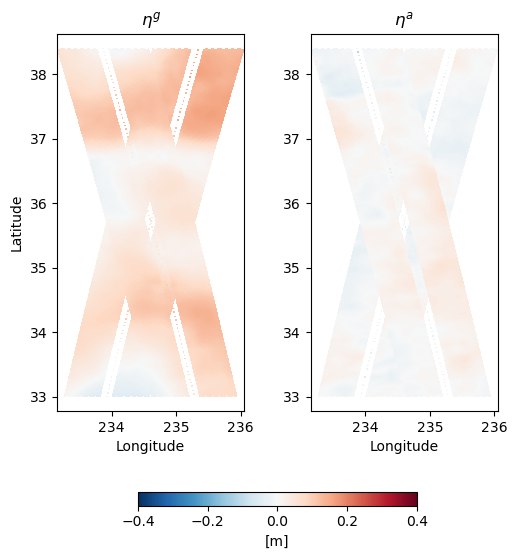

In [12]:
cnum = 20
fig, axes = plt.subplots(figsize=(6,7), nrows=1, ncols=2)
# fig.set_tight_layout(True)
im = axes[0].pcolormesh(g13_exterp.isel(cycle_num=cnum).longitude, 
                        g13_exterp.isel(cycle_num=cnum).latitude,
               g13_exterp.isel(cycle_num=cnum),
               vmin=-.4, vmax=.4, cmap="RdBu_r",
               rasterized=True)
axes[0].pcolormesh(g26_exterp.isel(cycle_num=cnum).longitude, 
                   g26_exterp.isel(cycle_num=cnum).latitude,
               g26_exterp.isel(cycle_num=cnum),
               vmin=-.4, vmax=.4, cmap="RdBu_r",
               rasterized=True)
axes[1].pcolormesh(a13_exterp.isel(cycle_num=cnum).longitude, 
                   a13_exterp.isel(cycle_num=cnum).latitude,
               a13_exterp.isel(cycle_num=cnum),
               vmin=-.4, vmax=.4, cmap="RdBu_r",
               rasterized=True)
axes[1].pcolormesh(a26_exterp.isel(cycle_num=cnum).longitude, 
                   a26_exterp.isel(cycle_num=cnum).latitude,
               a26_exterp.isel(cycle_num=cnum),
               vmin=-.4, vmax=.4, cmap="RdBu_r",
               rasterized=True)
axes[0].set_aspect("equal")
axes[1].set_aspect("equal")
axes[0].set_xlabel(r"Longitude")
axes[0].set_ylabel(r"Latitude")
axes[1].set_xlabel(r"Longitude")
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.6)
cbar.set_label(r"[m]")
axes[0].set_title(r"$\eta^g$")
axes[1].set_title(r"$\eta^a$")
plt.savefig(op.join(ddir,"../Figs/ssha-CC.pdf"))

In [13]:
Fg3 = xrft.power_spectrum(ar_g3.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fg3 = xrft.power_spectrum(Fg3.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa3 = xrft.power_spectrum(ar_a3.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fa3 = xrft.power_spectrum(Fa3.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fg6 = xrft.power_spectrum(ar_g6.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fg6 = xrft.power_spectrum(Fg6.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa6 = xrft.power_spectrum(ar_a6.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fa6 = xrft.power_spectrum(Fa6.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa = .5*(Fa3 + Fa6)
Fg = .5*(Fg3 + Fg6)
Fg, Fa

(<xarray.DataArray (freq_time: 105, freq_num_lines: 294)> Size: 247kB
 dask.array<mul, shape=(105, 294), dtype=float64, chunksize=(105, 294), chunktype=numpy.ndarray>
 Coordinates:
   * freq_time       (freq_time) float64 840B -5.732e-06 -5.622e-06 ... 5.732e-06
   * freq_num_lines  (freq_num_lines) float64 2kB -0.00025 ... 0.0002483,
 <xarray.DataArray (freq_time: 105, freq_num_lines: 294)> Size: 247kB
 dask.array<mul, shape=(105, 294), dtype=float64, chunksize=(105, 294), chunktype=numpy.ndarray>
 Coordinates:
   * freq_time       (freq_time) float64 840B -5.732e-06 -5.622e-06 ... 5.732e-06
   * freq_num_lines  (freq_num_lines) float64 2kB -0.00025 ... 0.0002483)

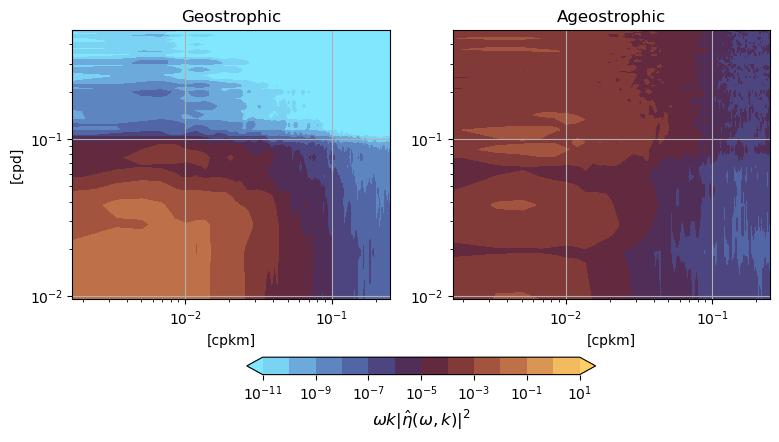

In [14]:
fig, axes = plt.subplots(figsize=(9,5), nrows=1, ncols=2)
# fig.set_tight_layout(True)
im = axes[0].contourf(Fg.freq_num_lines.isel(freq_num_lines=slice(len(Fg.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fg.freq_time.isel(freq_time=slice(len(Fg.freq_time)//2,
                                                 None)).values*86400,
               (Fg.freq_num_lines*Fg.freq_time*Fg
               ).isel(freq_num_lines=slice(len(Fg.freq_num_lines)//2,None),
                      freq_time=slice(len(Fg.freq_time)//2,None)
                     ).values.T*4,
               levels=np.logspace(-11,1,13),
               norm=clr.LogNorm(), cmap="managua_r",
               extend="both",
               rasterized=True
              )
axes[1].contourf(Fa.freq_num_lines.isel(freq_num_lines=slice(len(Fa.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fa.freq_time.isel(freq_time=slice(len(Fa.freq_time)//2,
                                                 None)).values*86400,
               (Fa.freq_num_lines*Fa.freq_time*Fa
               ).isel(freq_num_lines=slice(len(Fa.freq_num_lines)//2,None),
                      freq_time=slice(len(Fa.freq_time)//2,None)
                     ).values.T*4,
               levels=np.logspace(-11,1,13),
               norm=clr.LogNorm(), cmap="managua_r",
                 extend="both",
               rasterized=True
              )
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlim([Fg.freq_num_lines.where(Fg.freq_num_lines>0.).min()*1e3,
              Fg.freq_num_lines.where(Fg.freq_num_lines>0.).max()*1e3])
axes[0].set_ylim([Fg.freq_time.where(Fg.freq_time>0.).min()*86400,
              Fg.freq_time.where(Fg.freq_time>0.).max()*86400])
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlim([Fa.freq_num_lines.where(Fa.freq_num_lines>0.).min()*1e3,
              Fa.freq_num_lines.where(Fa.freq_num_lines>0.).max()*1e3])
axes[1].set_ylim([Fa.freq_time.where(Fa.freq_time>0.).min()*86400,
              Fa.freq_time.where(Fa.freq_time>0.).max()*86400])
axes[0].set_xlabel(r"[cpkm]")
axes[1].set_xlabel(r"[cpkm]")
axes[0].set_ylabel(r"[cpd]")
axes[0].grid(True)
axes[1].grid(True)
axes[0].set_title(r"Geostrophic")
axes[1].set_title(r"Ageostrophic")
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.5)
cbar.set_label(r"$\omega k |\hat{\eta}(\omega,k)|^2$", fontsize=12)
plt.savefig(op.join(ddir,"../Figs/omega-k_CC.pdf"))

In [22]:
dsv6 = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass026/SSVs_SwotDiag.zarr"))
dsv3 = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass013/SSVs_SwotDiag.zarr"))
dsv6r = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass026/SSVs_rawSwotDiag.zarr"))
dsv3r = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass013/SSVs_rawSwotDiag.zarr"))
dsv6, dsv3

(<xarray.Dataset> Size: 3GB
 Dimensions:     (cycle_num: 105, num_lines: 9310, num_pixels: 61)
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 74kB 1 2 3 4 5 6 ... 9854 9855 9856 9857 9858
   * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
     latitude    (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9310, 61), meta=np.ndarray>
     longitude   (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9310, 61), meta=np.ndarray>
 Data variables:
     strain      (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>
     ucg         (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>
     ug          (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>
     vcg         (cycle_num, num_lines, num_pixels) float64 477MB das

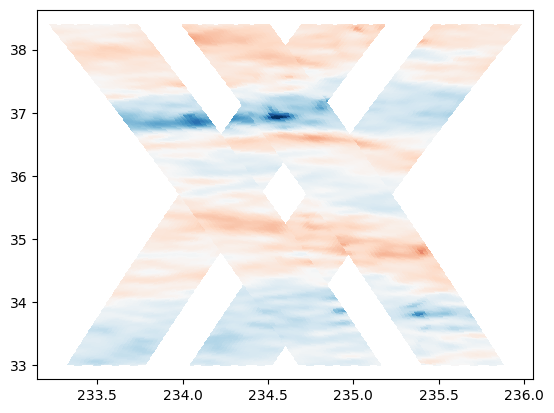

In [23]:
u3 = dsv3.ucg.where(~maskn3,drop=True).where(~masks3,drop=True)
u6 = dsv6.ucg.where(~maskn6,drop=True).where(~masks6,drop=True)

fig, ax = plt.subplots()
ax.pcolormesh(u3.longitude, u3.latitude,
              u3.isel(cycle_num=11),
              vmax=.8, vmin=-.8, cmap="RdBu_r",
              rasterized=True
             )
ax.pcolormesh(u6.longitude, u6.latitude,
              u6.isel(cycle_num=11),
              vmax=.8, vmin=-.8, cmap="RdBu_r",
              rasterized=True
             )

In [24]:
sp3 = np.sqrt(dsv3.ucg**2 + dsv3.vcg**2).where(~maskn3,drop=True).where(~masks3,drop=True)
sp6 = np.sqrt(dsv6.ucg**2 + dsv6.vcg**2).where(~maskn6,drop=True).where(~masks6,drop=True)
v3 = dsv3.vort.where(~maskn3,drop=True).where(~masks3,drop=True)
s3 = dsv3.strain.where(~maskn3,drop=True).where(~masks3,drop=True)
v6 = dsv6.vort.where(~maskn6,drop=True).where(~masks6,drop=True)
s6 = dsv6.strain.where(~maskn6,drop=True).where(~masks6,drop=True)
v3r = dsv3r.vort.where(~maskn3,drop=True
                      ).where(~masks3,drop=True
                             ).isel(num_pixels=slice(4,-4),
                                    num_lines=slice(1,-1)
                                   ).dropna("cycle_num", how="all")
s3r = dsv3r.strain.where(~maskn3,drop=True
                        ).where(~masks3,drop=True
                               ).isel(num_pixels=slice(4,-4),
                                      num_lines=slice(1,-1)
                                     ).dropna("cycle_num", how="all")
v6r = dsv6r.vort.where(~maskn6,drop=True
                      ).where(~masks6,drop=True
                             ).isel(num_pixels=slice(4,-4),
                                    num_lines=slice(1,-1)
                                   ).dropna("cycle_num", how="all")
s6r = dsv6r.strain.where(~maskn6,drop=True
                        ).where(~masks6,drop=True
                               ).isel(num_pixels=slice(4,-4),
                                      num_lines=slice(1,-1)
                                     ).dropna("cycle_num", how="all")
v3, v3r

(<xarray.DataArray 'vort' (cycle_num: 105, num_lines: 319, num_pixels: 61)> Size: 16MB
 dask.array<where, shape=(105, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 3kB 6776 6777 6778 6779 ... 7092 7093 7094
   * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
     latitude    (num_lines, num_pixels) float64 156kB 33.0 33.0 ... 38.39 38.38
     longitude   (num_lines, num_pixels) float64 156kB 233.3 233.3 ... 236.0,
 <xarray.DataArray 'vort' (cycle_num: 91, num_lines: 319, num_pixels: 61)> Size: 14MB
 dask.array<getitem, shape=(91, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 728B 474 478 479 480 481 ... 574 575 576 577
   * num_lines   (num_lines) int64 3kB 6776 6777 6778 6779 ... 7092 7093 7094
   * num_pixels  (num_pixels) in

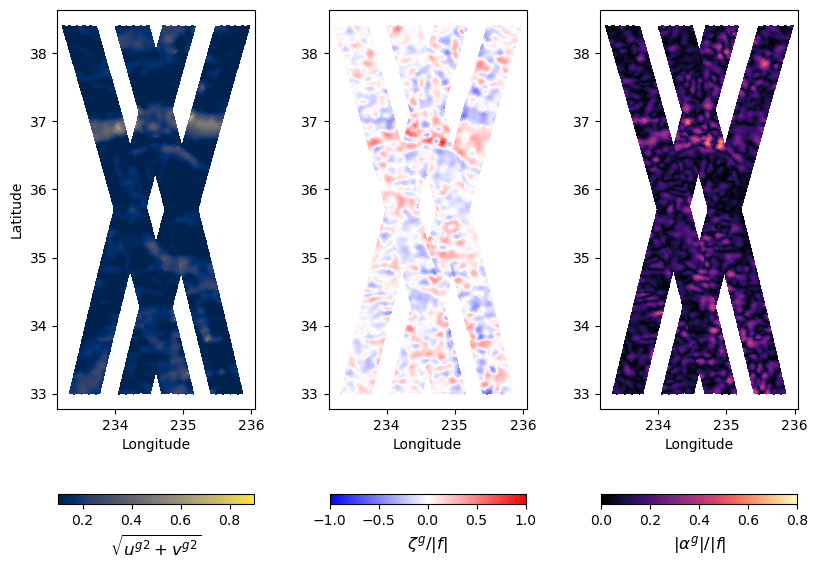

In [25]:
fig, (ax0, ax1,ax2) = plt.subplots(figsize=(9,6), nrows=1, ncols=3)
fig.set_tight_layout(True)
ax0.pcolormesh(sp3.isel(cycle_num=cnum).longitude, sp3.isel(cycle_num=cnum).latitude,
               sp3.isel(cycle_num=cnum),
               vmin=.1, vmax=.9, cmap="cividis",
               rasterized=True)
im0 = ax0.pcolormesh(sp6.isel(cycle_num=cnum).longitude, sp6.isel(cycle_num=cnum).latitude,
               sp6.isel(cycle_num=cnum),
               vmin=.1, vmax=.9, cmap="cividis",
               rasterized=True)
ax1.pcolormesh(v3.isel(cycle_num=cnum).longitude, v3.isel(cycle_num=cnum).latitude,
               (v3.isel(cycle_num=cnum) 
                / np.abs(gsw.f(v3.isel(cycle_num=cnum).latitude))),
               vmin=-1, vmax=1, cmap="bwr",
               rasterized=True)
im1 = ax1.pcolormesh(v6.isel(cycle_num=cnum).longitude, v6.isel(cycle_num=cnum).latitude,
               (v6.isel(cycle_num=cnum) 
                / np.abs(gsw.f(v6.isel(cycle_num=cnum).latitude))),
               vmin=-1, vmax=1, cmap="bwr",
               rasterized=True)
ax2.pcolormesh(s3.isel(cycle_num=cnum).longitude, s3.isel(cycle_num=cnum).latitude,
               (s3.isel(cycle_num=cnum) 
                / np.abs(gsw.f(s3.isel(cycle_num=cnum).latitude))),
               vmax=.8, vmin=0., cmap="magma",
               rasterized=True)
im2 = ax2.pcolormesh(s6.isel(cycle_num=cnum).longitude, s6.isel(cycle_num=cnum).latitude,
               (s6.isel(cycle_num=cnum) 
                / np.abs(gsw.f(s6.isel(cycle_num=cnum).latitude))),
               vmax=.8, vmin=0., cmap="magma",
               rasterized=True)
ax0.set_aspect("equal")
ax1.set_aspect("equal")
ax2.set_aspect("equal")
ax0.set_xlabel(r"Longitude")
ax1.set_xlabel(r"Longitude")
ax0.set_ylabel(r"Latitude")
ax2.set_xlabel(r"Longitude")
cbar0 = fig.colorbar(im0, ax=ax0, orientation="horizontal", shrink=.6)
cbar1 = fig.colorbar(im1, ax=ax1, orientation="horizontal", shrink=.6)
cbar2 = fig.colorbar(im2, ax=ax2, orientation="horizontal", shrink=.6)
cbar0.set_label(r"$\sqrt{{u^g}^2 + {v^g}^2}$", fontsize=12)
cbar1.set_label(r"$\zeta^g/|f|$", fontsize=12)
cbar2.set_label(r"$|\alpha^g|/|f|$", fontsize=12)
plt.savefig(op.join(ddir,"../Figs/vort-strain-CC.pdf"))

In [26]:
vort = xr.concat([v3.drop_vars(["cycle_num","num_lines","num_pixels"]),
                  v6.drop_vars(["cycle_num","num_lines","num_pixels"])
                 ], "cycle_num")
strain = xr.concat([s3.drop_vars(["cycle_num","num_lines","num_pixels"]),
                  s6.drop_vars(["cycle_num","num_lines","num_pixels"])
                 ], "cycle_num")
f = gsw.f(vort.latitude)
vort_raw = xr.concat([v3r.drop_vars(["cycle_num","num_lines","num_pixels"]),
                  v6r.drop_vars(["cycle_num","num_lines","num_pixels"])
                 ], "cycle_num")
str_raw = xr.concat([s3r.drop_vars(["cycle_num","num_lines","num_pixels"]),
                  s6r.drop_vars(["cycle_num","num_lines","num_pixels"])
                 ], "cycle_num")
fr = gsw.f(vort_raw.latitude)
vort, strain, f

(<xarray.DataArray 'vort' (cycle_num: 210, num_lines: 319, num_pixels: 61)> Size: 33MB
 dask.array<concatenate, shape=(210, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
     latitude   (cycle_num, num_lines, num_pixels) float64 33MB 33.0 ... 32.79
     longitude  (cycle_num, num_lines, num_pixels) float64 33MB 233.3 ... 234.7
 Dimensions without coordinates: cycle_num, num_lines, num_pixels,
 <xarray.DataArray 'strain' (cycle_num: 210, num_lines: 319, num_pixels: 61)> Size: 33MB
 dask.array<concatenate, shape=(210, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
     latitude   (cycle_num, num_lines, num_pixels) float64 33MB 33.0 ... 32.79
     longitude  (cycle_num, num_lines, num_pixels) float64 33MB 233.3 ... 234.7
 Dimensions without coordinates: cycle_num, num_lines, num_pixels,
 <xarray.DataArray 'latitude' (cycle_num: 210, num_lines: 319, num_pixels: 61)> Size: 33MB
 array([[[7.94417138e-05, 7.943

In [27]:
vbins = np.linspace(-3e0,3e0,60)
sbins = np.linspace(0,3e0,30)
hist_c = xhist((strain / np.abs(f)).rename('strain'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               (vort / np.abs(f)).rename('vort'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               bins=[sbins, vbins], density=True
              ).compute()
hist_r = xhist((str_raw / np.abs(fr)).rename('strain'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               (vort_raw / np.abs(fr)).rename('vort'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               bins=[sbins, vbins], density=True
              ).compute()

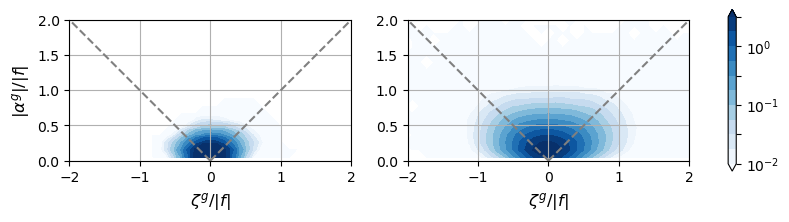

In [28]:
fig, axes = plt.subplots(figsize=(10,3), nrows=1, ncols=2)
# fig.set_tight_layout(True)

im = axes[0].contourf(hist_c.vort_bin,
                 hist_c.strain_bin,
                 hist_c, 
                 cmap='Blues', locator=ticker.LogLocator(), 
                 norm=clr.LogNorm(), levels=np.logspace(-2,.5,11),
                 extend='both'
#                       rasterized=True
               )
axes[1].contourf(hist_r.vort_bin,
                 hist_r.strain_bin,
                 hist_r, 
                 cmap='Blues', locator=ticker.LogLocator(), 
                 norm=clr.LogNorm(), levels=np.logspace(-2,.5,11),
                 extend='both'
#                       rasterized=True
               )

# for c in im.collections:
#     c.set_rasterized(True)

axes[0].plot(np.linspace(0,3,5),np.linspace(0,3,5),c='grey',ls='--')
axes[0].plot(np.linspace(-3,0,5),np.linspace(3,0,5),c='grey',ls='--')
axes[1].plot(np.linspace(0,3,5),np.linspace(0,3,5),c='grey',ls='--')
axes[1].plot(np.linspace(-3,0,5),np.linspace(3,0,5),c='grey',ls='--')

axes[0].set_xlim([-2,2])
axes[0].set_ylim([0,2])
axes[1].set_xlim([-2,2])
axes[1].set_ylim([0,2])

axes[0].set_xlabel(r"$\zeta^g/|f|$", fontsize=12)
axes[1].set_xlabel(r"$\zeta^g/|f|$", fontsize=12)
axes[0].set_ylabel(r"$|\alpha^g|/|f|$", fontsize=12)

axes[0].grid(True)
axes[0].set_aspect('equal')
axes[1].grid(True)
axes[1].set_aspect('equal')

# fig.subplots_adjust(hspace=.06, wspace=.12)
# cbar = fig.colorbar(im, orientation='horizontal', ax=axes, shrink=.4, 
#                     ticks=[1e-4,1e-3,1e-2,1e-1,1e0])
cbar = fig.colorbar(im, ax=axes, shrink=.7)
# cbar.set_ticks([1e-2,1e-1,0,1])

plt.savefig(op.join(ddir,"../Figs/vort-strain-CCjointPDF.pdf"))

# Med Sea

In [4]:
ds03 = xr.open_zarr(op.join(ddir,"SWOT_no_IT/CalVal_pass%03d_v2.0.1.zarr"
                            % 3))
ds03.coords["num_lines"] = ("num_lines",range(len(ds03.num_lines)))
ds03.coords["num_pixels"] = ("num_pixels",range(len(ds03.num_pixels)))

ds16 = xr.open_zarr(op.join(ddir,"SWOT_no_IT/CalVal_pass%03d_v2.0.1.zarr"
                            % 16))
ds16.coords["num_lines"] = ("num_lines",range(len(ds16.num_lines)))
ds16.coords["num_pixels"] = ("num_pixels",range(len(ds16.num_pixels)))
ds03,ds16

(<xarray.Dataset> Size: 582MB
 Dimensions:       (cycle_num: 105, num_lines: 9860, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 79kB 0 1 2 3 4 ... 9855 9856 9857 9858 9859
   * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 68
     latitude      (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9860, 69), meta=np.ndarray>
     longitude     (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9860, 69), meta=np.ndarray>
 Data variables:
     ssha_detided  (cycle_num, num_lines, num_pixels) float64 571MB dask.array<chunksize=(1, 9860, 69), meta=np.ndarray>,
 <xarray.Dataset> Size: 582MB
 Dimensions:       (cycle_num: 105, num_lines: 9860, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 79kB 0 1 2 3 4 ... 9855 9856 9857 9858 9859
   * num_pixels  

In [47]:
maskn3 = xr.DataArray(ds03.latitude.where(ds03.latitude<43.5).where(ds03.longitude>0.).to_masked_array().mask,
                     dims=ds03.latitude.dims,
                     coords=ds03.latitude.coords
                    )
masks3 = xr.DataArray(ds03.latitude.where(ds03.latitude>36.5).where(ds03.longitude>0.).to_masked_array().mask,
                     dims=ds03.latitude.dims,
                     coords=ds03.latitude.coords
                    )

maskn6 = xr.DataArray(ds16.latitude.where(ds16.latitude<43.5).where(ds03.longitude>0.).to_masked_array().mask,
                     dims=ds16.latitude.dims,
                     coords=ds16.latitude.coords
                    )
masks6 = xr.DataArray(ds16.latitude.where(ds16.latitude>36.5).where(ds03.longitude>0.).to_masked_array().mask,
                     dims=ds16.latitude.dims,
                     coords=ds16.latitude.coords
                    )
low03 = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass%03d/SSHa.zarr" 
                               % 3)
                      ).ssha.where(~maskn3,drop=True).where(~masks3,drop=True)
low16 = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass%03d/SSHa.zarr" 
                               % 16)
                      ).ssha.where(~maskn6,drop=True).where(~masks6,drop=True)
low03, low16

(<xarray.DataArray 'ssha' (cycle_num: 105, num_lines: 414, num_pixels: 61)> Size: 21MB
 dask.array<where, shape=(105, 414, 61), dtype=float64, chunksize=(1, 414, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 3kB 6974 6975 6976 6977 ... 7385 7386 7387
   * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
     latitude    (num_lines, num_pixels) float64 202kB 36.51 36.5 ... 43.5 43.5
     longitude   (num_lines, num_pixels) float64 202kB 2.701 2.723 ... 6.296,
 <xarray.DataArray 'ssha' (cycle_num: 105, num_lines: 414, num_pixels: 61)> Size: 21MB
 dask.array<where, shape=(105, 414, 61), dtype=float64, chunksize=(1, 414, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 3kB 2474 2475 2476 2477 ... 2885 2886 2887
   * num_pixels  (num_pixels) int

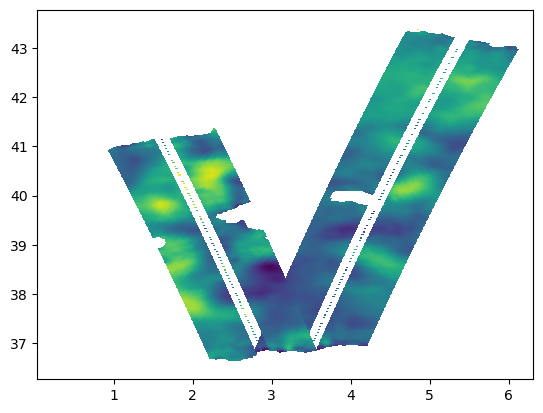

In [48]:
fig, ax = plt.subplots()
ax.pcolormesh(low03.longitude, low03.latitude,
              low03.isel(cycle_num=10),
              rasterized=True
             )
ax.pcolormesh(low16.longitude, low16.latitude,
              low16.isel(cycle_num=10),
              rasterized=True
             )

In [43]:
dsv6 = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass016/SSVs_SwotDiag.zarr")
                   ).where(~maskn6,drop=True).where(~masks6,drop=True)
dsv3 = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass003/SSVs_SwotDiag.zarr")
                   ).where(~maskn3,drop=True).where(~masks3,drop=True)
dsv6

<xarray.Dataset> Size: 126MB
Dimensions:     (cycle_num: 105, num_lines: 408, num_pixels: 61)
Coordinates:
  * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * num_lines   (num_lines) int64 3kB 2480 2481 2482 2483 ... 2885 2886 2887
  * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
    latitude    (num_lines, num_pixels) float64 199kB 43.66 43.66 ... 36.28
    longitude   (num_lines, num_pixels) float64 199kB 1.529 1.505 ... 2.362 2.34
Data variables:
    strain      (cycle_num, num_lines, num_pixels) float64 21MB dask.array<chunksize=(1, 408, 61), meta=np.ndarray>
    ucg         (cycle_num, num_lines, num_pixels) float64 21MB dask.array<chunksize=(1, 408, 61), meta=np.ndarray>
    ug          (cycle_num, num_lines, num_pixels) float64 21MB dask.array<chunksize=(1, 408, 61), meta=np.ndarray>
    vcg         (cycle_num, num_lines, num_pixels) float64 21MB dask.array<chunksize=(1, 408, 61), meta=np.ndarray>
    vg          (cycle_num, num_lines, num_pixels) float64 21MB dask.array<chunksize=(1, 408, 61), meta=np.ndarray>
    vort        (cycle_num, num_lines, num_pixels) float64 21MB dask.array<chunksize=(1, 408, 61), meta=np.ndarray>

In [44]:
wMed3 = xr.merge([low03.to_dataset(name="sshg"),dsv3])
wMed6 = xr.merge([low16.to_dataset(name="sshg"),dsv6])
wMed6

<xarray.Dataset> Size: 147MB
Dimensions:     (cycle_num: 105, num_lines: 408, num_pixels: 61)
Coordinates:
  * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * num_lines   (num_lines) int64 3kB 2480 2481 2482 2483 ... 2885 2886 2887
  * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
    latitude    (num_lines, num_pixels) float64 199kB 43.66 43.66 ... 36.28
    longitude   (num_lines, num_pixels) float64 199kB 1.529 1.505 ... 2.362 2.34
Data variables:
    sshg        (cycle_num, num_lines, num_pixels) float64 21MB dask.array<chunksize=(1, 408, 61), meta=np.ndarray>
    strain      (cycle_num, num_lines, num_pixels) float64 21MB dask.array<chunksize=(1, 408, 61), meta=np.ndarray>
    ucg         (cycle_num, num_lines, num_pixels) float64 21MB dask.array<chunksize=(1, 408, 61), meta=np.ndarray>
    ug          (cycle_num, num_lines, num_pixels) float64 21MB dask.array<chunksize=(1, 408, 61), meta=np.ndarray>
    vcg         (cycle_num, num_lines, num_pixels) float64 21MB dask.array<chunksize=(1, 408, 61), meta=np.ndarray>
    vg          (cycle_num, num_lines, num_pixels) float64 21MB dask.array<chunksize=(1, 408, 61), meta=np.ndarray>
    vort        (cycle_num, num_lines, num_pixels) float64 21MB dask.array<chunksize=(1, 408, 61), meta=np.ndarray>

In [46]:
wMed3.to_zarr(op.join(ddir,"CalVal/geos/westMed/SSVs_pass003.zarr"))
wMed6.to_zarr(op.join(ddir,"CalVal/geos/westMed/SSVs_pass016.zarr"))